# Spectral Exploration

Exploratory eigenvector analysis for a spectral clustering pipeline. This notebook sweeps across three affinity constructions and three Laplacian normalisations, examining the structure of eigenvectors and spectral gaps for three synthetic datasets.

## Section 1 — Imports and Configuration

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh, eig, expm
from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances

%matplotlib inline

# cc  : cluster count (true number of clusters)
# q_max = 2*cc + 1 is computed automatically per dataset below
CONFIG = {
    "seed":      42,
    "n_samples": 500,
    "noise":     0.1,
    "knn_k":     10,
    "t":         1.0,
    "datasets": {
        "Blobs":   {"cc": 7, "sigma": 10.0},
        "Circles": {"cc": 3, "sigma": 0.25},
        "Moons":   {"cc": 2, "sigma": 0.1},
    },
}

for _cfg in CONFIG["datasets"].values():
    _cfg["q_max"] = 2 * _cfg["cc"] + 1

np.random.seed(CONFIG["seed"])

## Section 2 — Data Generation

Three synthetic datasets are generated using `sklearn.datasets`. Each has `N = 500` points with ground truth cluster labels.

In [10]:
datasets = {}

X_blobs, y_blobs = make_blobs(
    n_samples=CONFIG["n_samples"],
    centers=CONFIG["datasets"]["Blobs"]["cc"],
    random_state=CONFIG["seed"],
)
datasets["Blobs"] = (X_blobs, y_blobs)

X_circles, y_circles = make_circles(
    n_samples=CONFIG["n_samples"],
    noise=CONFIG["noise"],
    random_state=CONFIG["seed"],
)
datasets["Circles"] = (X_circles, y_circles)

X_moons, y_moons = make_moons(
    n_samples=CONFIG["n_samples"],
    noise=CONFIG["noise"],
    random_state=CONFIG["seed"],
)
datasets["Moons"] = (X_moons, y_moons)

for ds_name, (X, y) in datasets.items():
    n_actual = len(np.unique(y))
    cc_cfg   = CONFIG["datasets"][ds_name]["cc"]
    print(f"{ds_name:8s}  X={X.shape}  actual clusters={n_actual}  cc (config)={cc_cfg}")

Blobs     X=(500, 5000)  actual clusters=7  cc (config)=7
Circles   X=(500, 2)  actual clusters=2  cc (config)=3
Moons     X=(500, 2)  actual clusters=2  cc (config)=2


## Section 3 — Pipeline

The full pipeline is executed for each dataset across all combinations of three affinity constructions and three Laplacian normalisations, yielding nine combination per dataset.

### Affinity Construction

Three affinity matrices are constructed:

1. **Fully connected Gaussian** — all pairwise Gaussian weights.
2. **kNN Gaussian** — Gaussian weights masked to the OR-symmetrised k-nearest-neighbour graph.
3. **Diffusion kernel** — `K_t = expm(-t * A)` where `A` is the kNN Gaussian affinity.

In [11]:
def gaussian_affinity(X, sigma):
    """
    Compute the fully connected Gaussian affinity matrix.

    Parameters
    ----------
    X : ndarray of shape (N, d)
    sigma : float
        Gaussian kernel bandwidth.

    Returns
    -------
    W : ndarray of shape (N, N)
    """
    sq_dists = pairwise_distances(X, metric="euclidean") ** 2
    return np.exp(-sq_dists / (2.0 * sigma ** 2))


def build_knn_mask(X, k):
    """
    Compute the OR-symmetrised k-nearest-neighbour binary connectivity mask.

    Parameters
    ----------
    X : ndarray of shape (N, d)
    k : int
        Number of nearest neighbours.

    Returns
    -------
    mask : ndarray of shape (N, N)
    """
    nbrs  = NearestNeighbors(n_neighbors=k + 1, metric="euclidean").fit(X)
    graph = nbrs.kneighbors_graph(mode="connectivity").toarray()
    np.fill_diagonal(graph, 0.0)
    return np.maximum(graph, graph.T)


def knn_gaussian_affinity(X, sigma, k):
    """
    Compute the kNN-masked Gaussian affinity matrix (OR symmetrisation).

    Parameters
    ----------
    X : ndarray of shape (N, d)
    sigma : float
    k : int

    Returns
    -------
    W : ndarray of shape (N, N)
    """
    return gaussian_affinity(X, sigma) * build_knn_mask(X, k)


def diffusion_kernel(X, sigma, k, t):
    """
    Compute the diffusion kernel K_t = expm(-t * A) via matrix exponential.

    A is the OR-symmetrised kNN Gaussian affinity matrix.

    Parameters
    ----------
    X : ndarray of shape (N, d)
    sigma : float
    k : int
    t : float
        Diffusion time. Future sweeps can iterate over this parameter.

    Returns
    -------
    K : ndarray of shape (N, N)
    """
    A = knn_gaussian_affinity(X, sigma, k)
    return expm(-t * A)

### Laplacian Construction

Three Laplacian normalisations are constructed from a given affinity matrix `A`:

- **Unnormalised** — `L = D - A`
- **Symmetrically normalised** — `L_sym = I - D^{-1/2} A D^{-1/2}`
- **Random-walk** — `L_rw = I - D^{-1} A`

In [13]:
def build_laplacian(A, laplacian_type):
    """
    Construct a graph Laplacian from affinity matrix A.

    Parameters
    ----------
    A : ndarray of shape (N, N)
        Symmetric affinity matrix.
    laplacian_type : str
        One of 'unnorm', 'sym', 'rw'.

    Returns
    -------
    L : ndarray of shape (N, N)
    d : ndarray of shape (N,)
        Degree vector.
    is_symmetric : bool
    """
    d = A.sum(axis=1)
    n = len(d)
    I = np.eye(n)

    if laplacian_type == "unnorm":
        D = np.diag(d)
        L = D - A
        is_symmetric = True

    elif laplacian_type == "sym":
        d_inv_sqrt = 1.0 / np.sqrt(np.maximum(d, 1e-12))
        D_inv_sqrt = np.diag(d_inv_sqrt)
        L = I - D_inv_sqrt @ A @ D_inv_sqrt
        is_symmetric = True

    elif laplacian_type == "rw":
        d_inv = 1.0 / np.maximum(d, 1e-12)
        D_inv = np.diag(d_inv)
        L = I - D_inv @ A
        is_symmetric = False

    else:
        raise ValueError(
            f"Unknown laplacian_type: {laplacian_type!r}. "
            f"Choose from 'unnorm', 'sym', 'rw'."
        )

    return L, d, is_symmetric

### Spectral Embedding

The spectral embedding uses `eigh` for symmetric Laplacians (unnormalised and symmetric) and `eig` with real-part extraction for the asymmetric random-walk Laplacian. The symmetric normalised Laplacian triggers NJW row normalisation after truncation.

In [14]:
def spectral_embedding(L, r, is_symmetric, laplacian_type):
    """
    Compute the r-dimensional spectral embedding of Laplacian L.

    Parameters
    ----------
    L : ndarray (n, n)
    r : int
        Number of eigenvectors to retain.
    is_symmetric : bool
        True uses eigh; False uses eig with real-part extraction.
    laplacian_type : str
        'sym' triggers NJW row normalisation.

    Returns
    -------
    U : ndarray (n, r)
        Spectral embedding.
    eigenvalues : ndarray (r,)
        Ascending eigenvalues.
    """
    if is_symmetric:
        eigenvalues, eigenvectors = eigh(L)
    else:
        eigenvalues_c, eigenvectors_c = eig(L)
        eigenvalues  = eigenvalues_c.real
        eigenvectors = eigenvectors_c.real
        sort_idx     = np.argsort(eigenvalues)
        eigenvalues  = eigenvalues[sort_idx]
        eigenvectors = eigenvectors[:, sort_idx]

    U       = eigenvectors[:, :r]
    lambdas = eigenvalues[:r]

    if laplacian_type == "sym":
        row_norms = np.sqrt(np.sum(U**2, axis=1, keepdims=True))
        U = U / np.maximum(row_norms, 1e-12)

    return U, lambdas

### Run Pipeline

All nine affinity–Laplacian combinations are computed for each of the three datasets. Results are stored in a nested dictionary keyed by `dataset -> affinity -> laplacian`.

In [15]:
AFFINITIES = ["fc_gaussian", "knn_gaussian", "diffusion"]
LAPLACIANS = ["unnorm", "sym", "rw"]

results = {}

for ds_name, (X, labels) in datasets.items():
    ds_cfg = CONFIG["datasets"][ds_name]
    sigma  = ds_cfg["sigma"]
    q_max  = ds_cfg["q_max"]
    k      = CONFIG["knn_k"]
    t      = CONFIG["t"]

    print(f"\n{'='*60}")
    print(f"Dataset: {ds_name}  |  cc={ds_cfg['cc']}  |  q_max={q_max}")
    print(f"{'='*60}")

    results[ds_name] = {}

    print("  Building fc_gaussian and knn_gaussian affinities...")
    A_fc  = gaussian_affinity(X, sigma)
    A_knn = knn_gaussian_affinity(X, sigma, k)

    print("  Computing diffusion kernel via matrix exponential...")
    A_diff = diffusion_kernel(X, sigma, k, t)

    affinity_matrices = {
        "fc_gaussian":  A_fc,
        "knn_gaussian": A_knn,
        "diffusion":    A_diff,
    }

    for aff_name, A in affinity_matrices.items():
        results[ds_name][aff_name] = {}

        for lap_name in LAPLACIANS:
            L, _d, is_sym = build_laplacian(A, lap_name)
            U, lambdas    = spectral_embedding(L, q_max, is_sym, lap_name)
            results[ds_name][aff_name][lap_name] = {
                "U":       U,
                "lambdas": lambdas,
            }
            print(f"    {aff_name:14s} | {lap_name:6s} — done")

print("\nPipeline complete.")


Dataset: Blobs  |  cc=7  |  q_max=15
  Building fc_gaussian and knn_gaussian affinities...
  Computing diffusion kernel via matrix exponential...
    fc_gaussian    | unnorm — done
    fc_gaussian    | sym    — done
    fc_gaussian    | rw     — done
    knn_gaussian   | unnorm — done
    knn_gaussian   | sym    — done
    knn_gaussian   | rw     — done
    diffusion      | unnorm — done
    diffusion      | sym    — done
    diffusion      | rw     — done

Dataset: Circles  |  cc=3  |  q_max=7
  Building fc_gaussian and knn_gaussian affinities...
  Computing diffusion kernel via matrix exponential...
    fc_gaussian    | unnorm — done
    fc_gaussian    | sym    — done
    fc_gaussian    | rw     — done
    knn_gaussian   | unnorm — done
    knn_gaussian   | sym    — done
    knn_gaussian   | rw     — done
    diffusion      | unnorm — done
    diffusion      | sym    — done
    diffusion      | rw     — done

Dataset: Moons  |  cc=2  |  q_max=5
  Building fc_gaussian and knn_gaussia

## Section 4 — Eigenvector Analysis Figures

Three analysis functions are defined below. Each accepts an optional `ax` argument for embedding in larger figures. All figures are produced for all nine affinity–Laplacian combinations across all three datasets.

### Function 1 — Raw Eigenvector Heatmap

Displays the `(N, q)` eigenvector matrix with nodes sorted by ground truth label. Horizontal lines mark cluster boundaries; a vertical dashed line marks the signal/noise boundary at eigenvector index `cc`.

In [16]:
def plot_raw_eigenvector_heatmap(Phi, labels, cc, q, title, ax=None):
    """
    Plot a heatmap of the raw eigenvector matrix with nodes sorted by ground truth label.

    Parameters
    ----------
    Phi : ndarray of shape (N, q_max)
        Full eigenvector matrix.
    labels : ndarray of shape (N,)
        Ground truth cluster labels.
    cc : int
        Cluster count (true number of clusters).
    q : int
        Number of eigenvectors to display. Must satisfy q <= q_max.
    title : str
        Plot title indicating the affinity and Laplacian combination.
    ax : matplotlib Axes, optional
        If provided, plot into this Axes; otherwise a new figure is created.

    Returns
    -------
    ax : matplotlib Axes
    """
    sort_idx      = np.argsort(labels, kind="stable")
    Phi_sorted    = Phi[sort_idx, :q]
    labels_sorted = labels[sort_idx]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(max(8, q + 2), 8))

    vmin = Phi_sorted.min()
    vmax = Phi_sorted.max()

    im = ax.imshow(
        Phi_sorted,
        aspect="auto",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        origin="upper",
        interpolation="nearest",
    )

    _, counts = np.unique(labels_sorted, return_counts=True)
    for boundary in np.cumsum(counts)[:-1]:
        ax.axhline(boundary - 0.5, color="black", linewidth=0.8)

    if cc - 1 < q:
        ax.axvline(cc - 0.5, color="lime", linewidth=2.0,
                   linestyle="--", label=f"cc = {cc}")
        ax.legend(loc="upper right", fontsize=8, framealpha=0.7)

    ax.set_xlabel("Eigenvector index")
    ax.set_ylabel("Node index")
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(q))
    ax.set_xticklabels(
        [f"phi_{i}" for i in range(q)], fontsize=7, rotation=60, ha="right"
    )

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    if standalone:
        plt.tight_layout()

    return ax

### Function 2 — Cluster Mean Eigenvector Heatmap

Displays a `(cc_actual, q)` heatmap where entry `(j, i)` is the mean value of eigenvector `phi_i` within cluster `j`. Colour limits are global across the displayed matrix.

In [17]:
def plot_cluster_mean_heatmap(Phi, labels, cc, q, title, ax=None):
    """
    Plot a heatmap of cluster-mean eigenvector values.

    Entry (j, i) is the mean value of eigenvector phi_i within cluster j.

    Parameters
    ----------
    Phi : ndarray of shape (N, q_max)
    labels : ndarray of shape (N,)
    cc : int
        Cluster count; governs the signal/noise boundary line position.
    q : int
        Number of eigenvectors to display.
    title : str
        Plot title indicating the affinity and Laplacian combination.
    ax : matplotlib Axes, optional

    Returns
    -------
    ax : matplotlib Axes
    """
    unique_labels = np.unique(labels)
    means = np.array([
        Phi[labels == lbl, :q].mean(axis=0)
        for lbl in unique_labels
    ])

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(
            figsize=(max(8, q + 2), max(3, len(unique_labels) + 1))
        )

    vmin = means.min()
    vmax = means.max()

    im = ax.imshow(
        means,
        aspect="auto",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
    )

    if cc - 1 < q:
        ax.axvline(cc - 0.5, color="lime", linewidth=2.0,
                   linestyle="--", label=f"cc = {cc}")
        ax.legend(loc="upper right", fontsize=8, framealpha=0.7)

    ax.set_xticks(range(q))
    ax.set_xticklabels(
        [f"phi_{i}" for i in range(q)], fontsize=7, rotation=60, ha="right"
    )
    ax.set_yticks(range(len(unique_labels)))
    ax.set_yticklabels([f"Cluster {lbl}" for lbl in unique_labels])
    ax.set_xlabel("Eigenvector index")
    ax.set_ylabel("Cluster")
    ax.set_title(title, fontsize=10)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    if standalone:
        plt.tight_layout()

    return ax

### Function 3 — Spectral Gap Profile

Two side-by-side panels:
- **Left** — eigenvalue sequence `lambda_0, ..., lambda_{2*cc}` with a red dashed line at the true `cc`.
- **Right** — successive gaps `lambda_{i+1} - lambda_i` as a bar chart with a red dashed line at `cc - 0.5`.

In [18]:
def plot_spectral_gap(lambdas, cc, title, ax=None):
    """
    Plot the eigenvalue sequence and successive spectral gaps side by side.

    Parameters
    ----------
    lambdas : ndarray
        Ascending eigenvalue sequence of length q_max = 2*cc + 1.
    cc : int
        Cluster count; marks the signal/noise boundary.
    title : str
        Overall figure title.
    ax : array-like of two matplotlib Axes, optional
        If provided, plot into these two Axes; otherwise a new figure is created.

    Returns
    -------
    fig : matplotlib Figure
        Returned when axes are created internally.
    ax : array of matplotlib Axes
        Returned when axes are supplied externally.
    """
    gaps = np.diff(lambdas)
    n    = len(lambdas)

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(title, fontsize=11)

    # Left panel — eigenvalue sequence
    ax[0].plot(range(n), lambdas, "o-", markersize=5,
               linewidth=1.5, label="lambda_i")
    ax[0].axvline(cc, color="red", linestyle="--",
                  linewidth=1.5, label=f"cc = {cc}")
    ax[0].set_xlabel("Index i")
    ax[0].set_ylabel("Eigenvalue lambda_i")
    ax[0].set_xlim(-0.5, n - 0.5)
    ax[0].legend(fontsize=9)
    ax[0].set_title("Eigenvalue sequence")

    # Right panel — successive gaps
    ax[1].bar(range(len(gaps)), gaps, color="steelblue",
              alpha=0.85, label="lambda_{i+1} - lambda_i")
    ax[1].axvline(cc - 0.5, color="red", linestyle="--",
                  linewidth=1.5, label=f"cc = {cc}")
    ax[1].set_xlabel("Index i")
    ax[1].set_ylabel("Gap lambda_{i+1} - lambda_i")
    ax[1].set_xlim(-0.5, len(gaps) - 0.5)
    ax[1].legend(fontsize=9)
    ax[1].set_title("Spectral gap profile")

    if standalone:
        plt.tight_layout()
        return fig

    return ax

### Generate All Figures

All three analysis functions are called for every affinity–Laplacian combination across all three datasets (27 combinations × 3 functions = 81 figures). Each figure is produced as a separate standalone plot.

For **Function 1**, `q` is set to `q_max` per dataset. To sweep `q` from `cc` to `q_max`, replace the single call with a loop over `range(cc, q_max + 1)`.

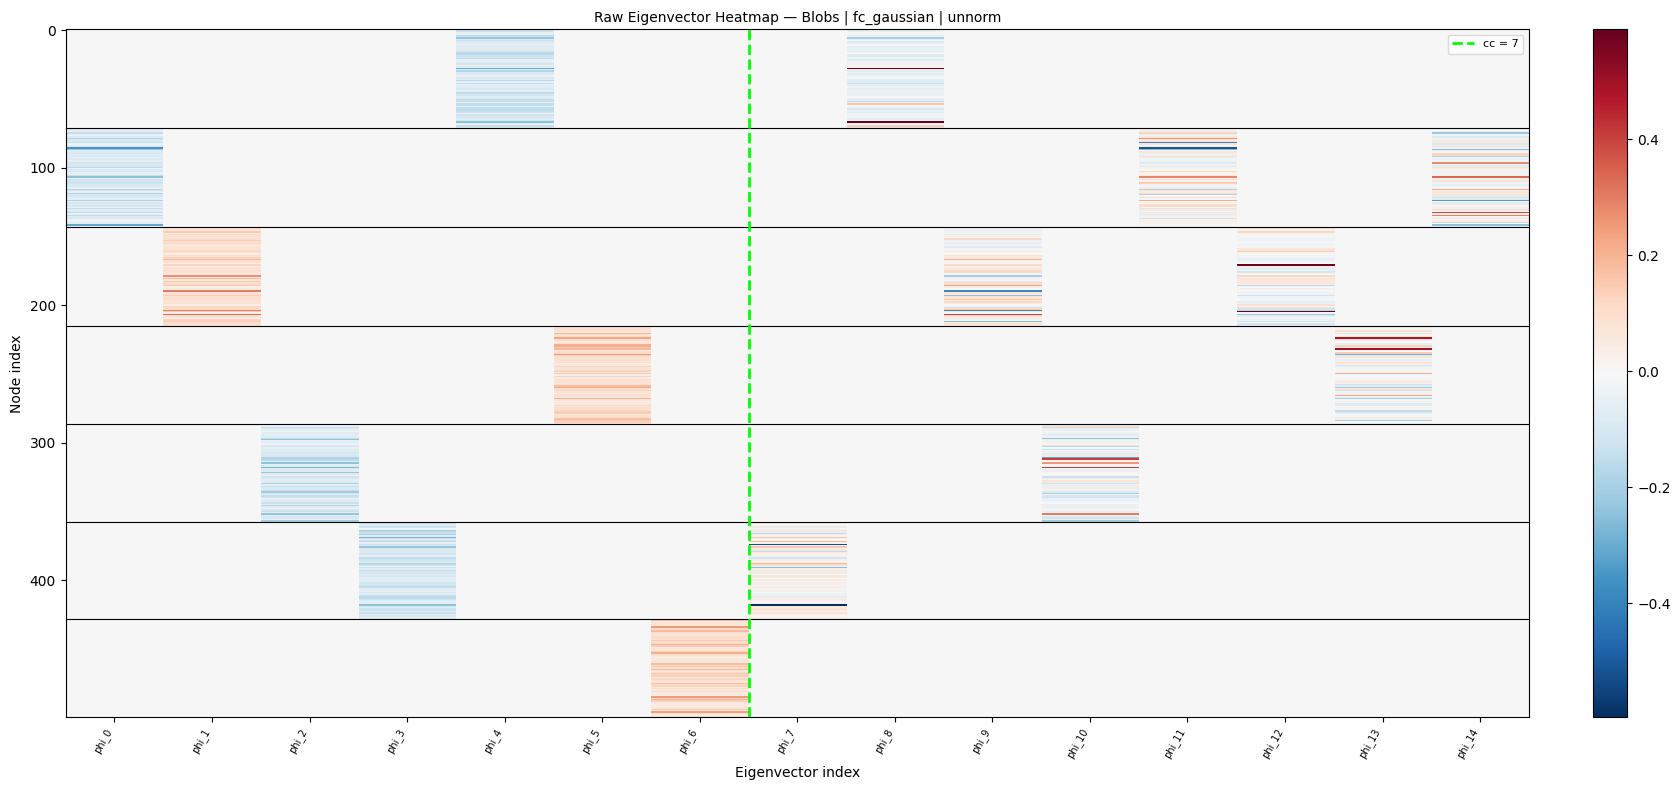

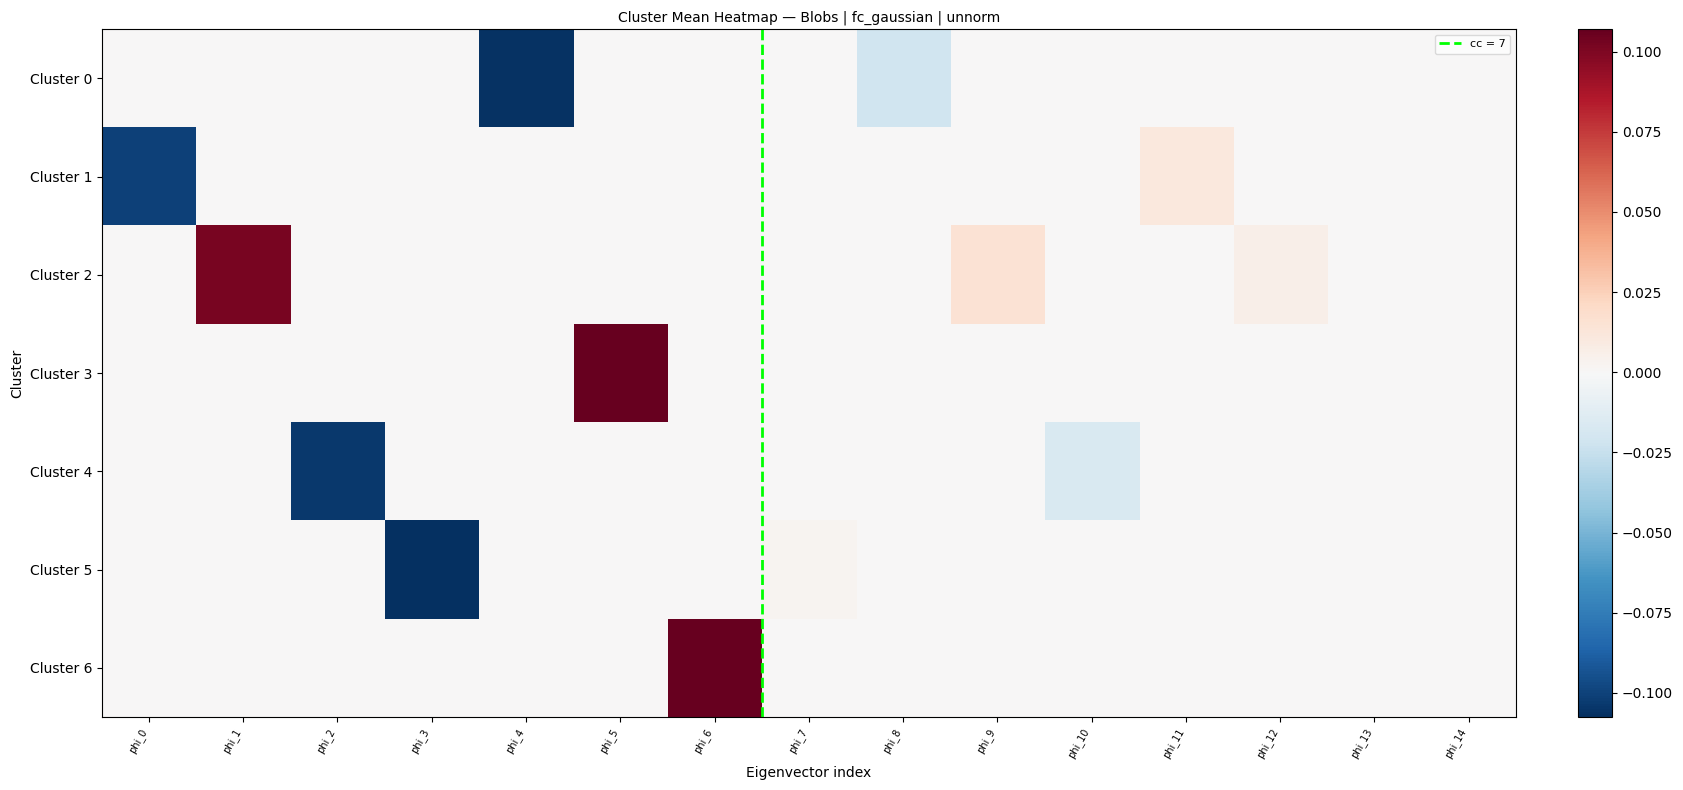

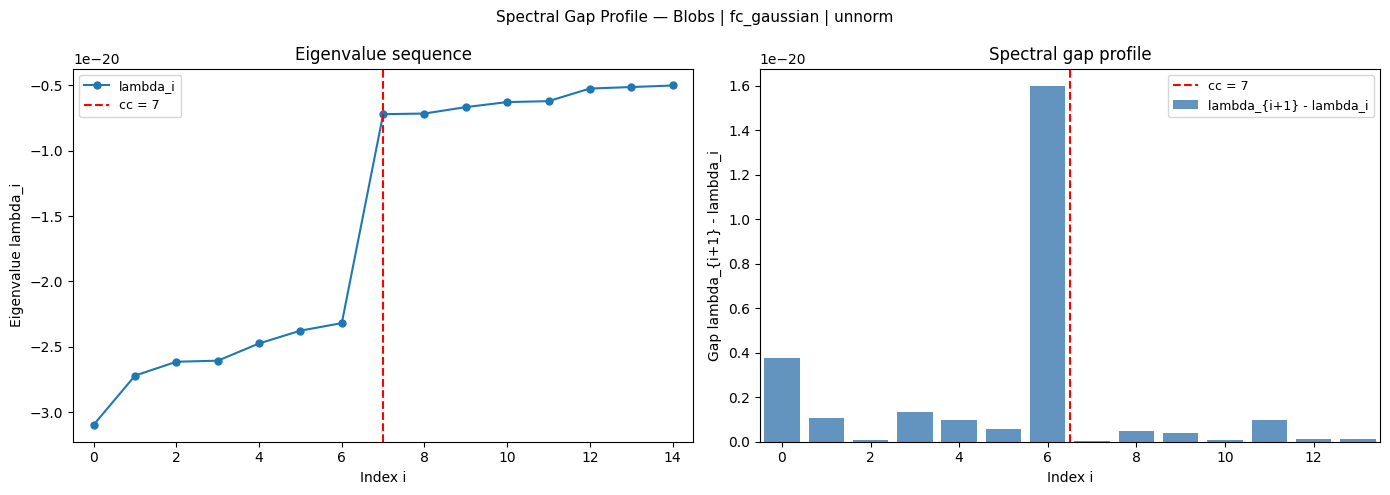

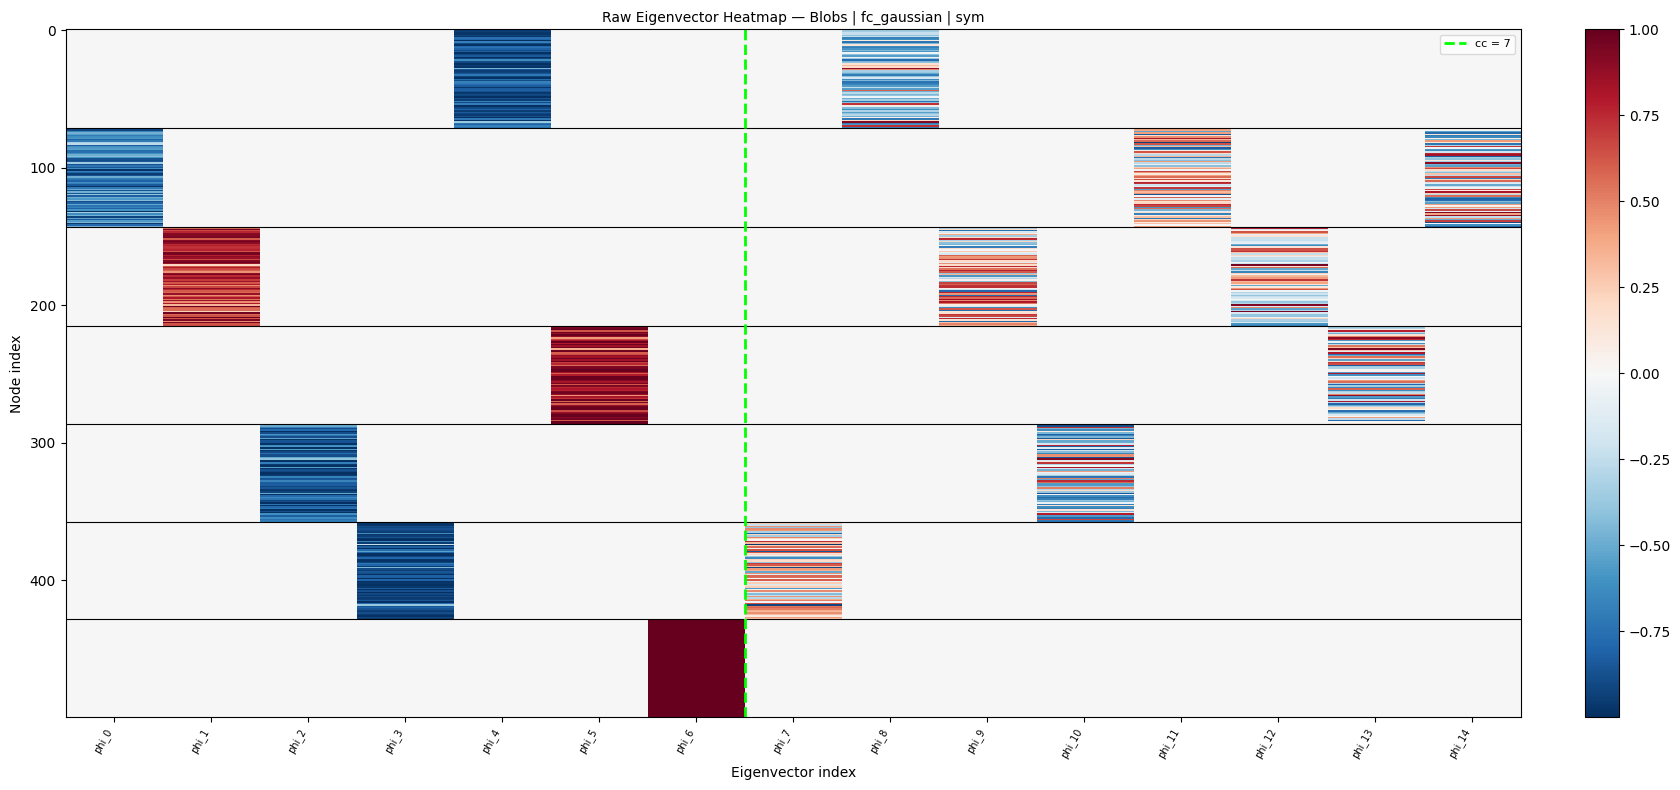

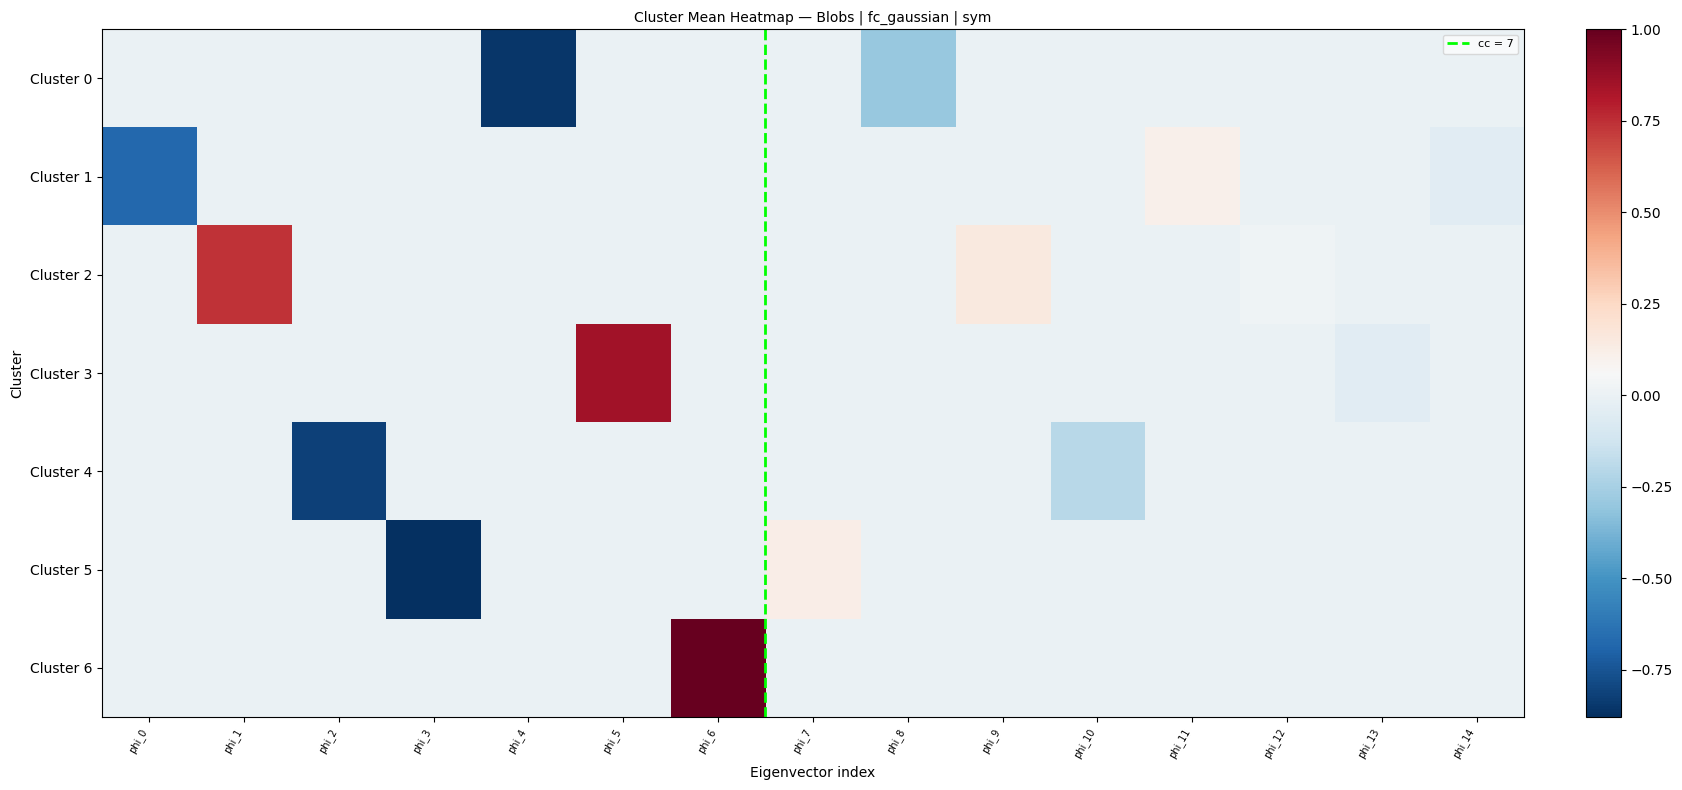

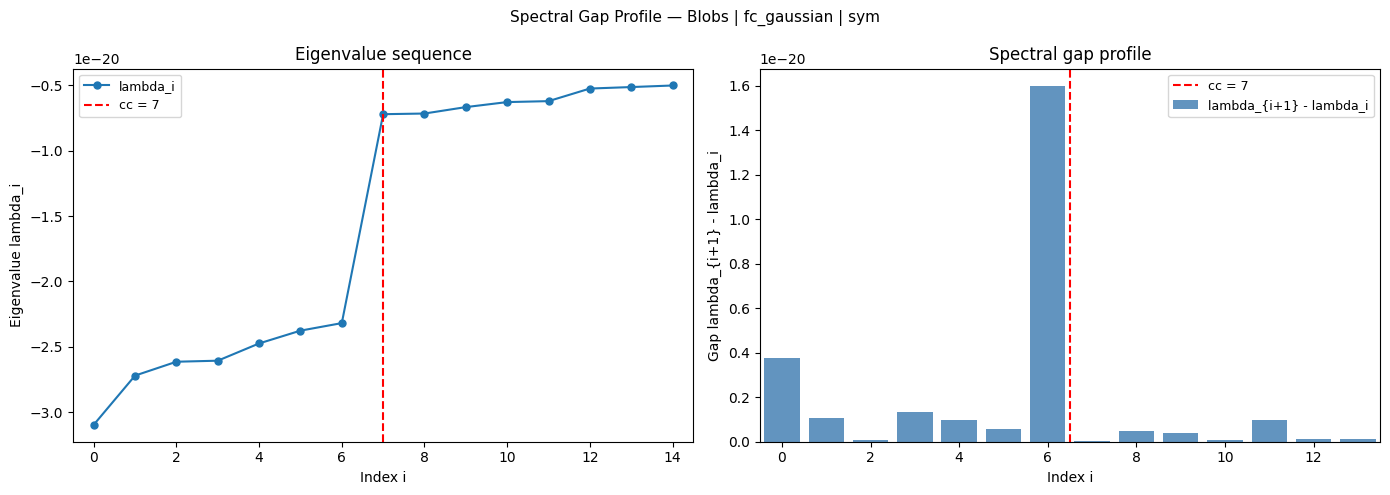

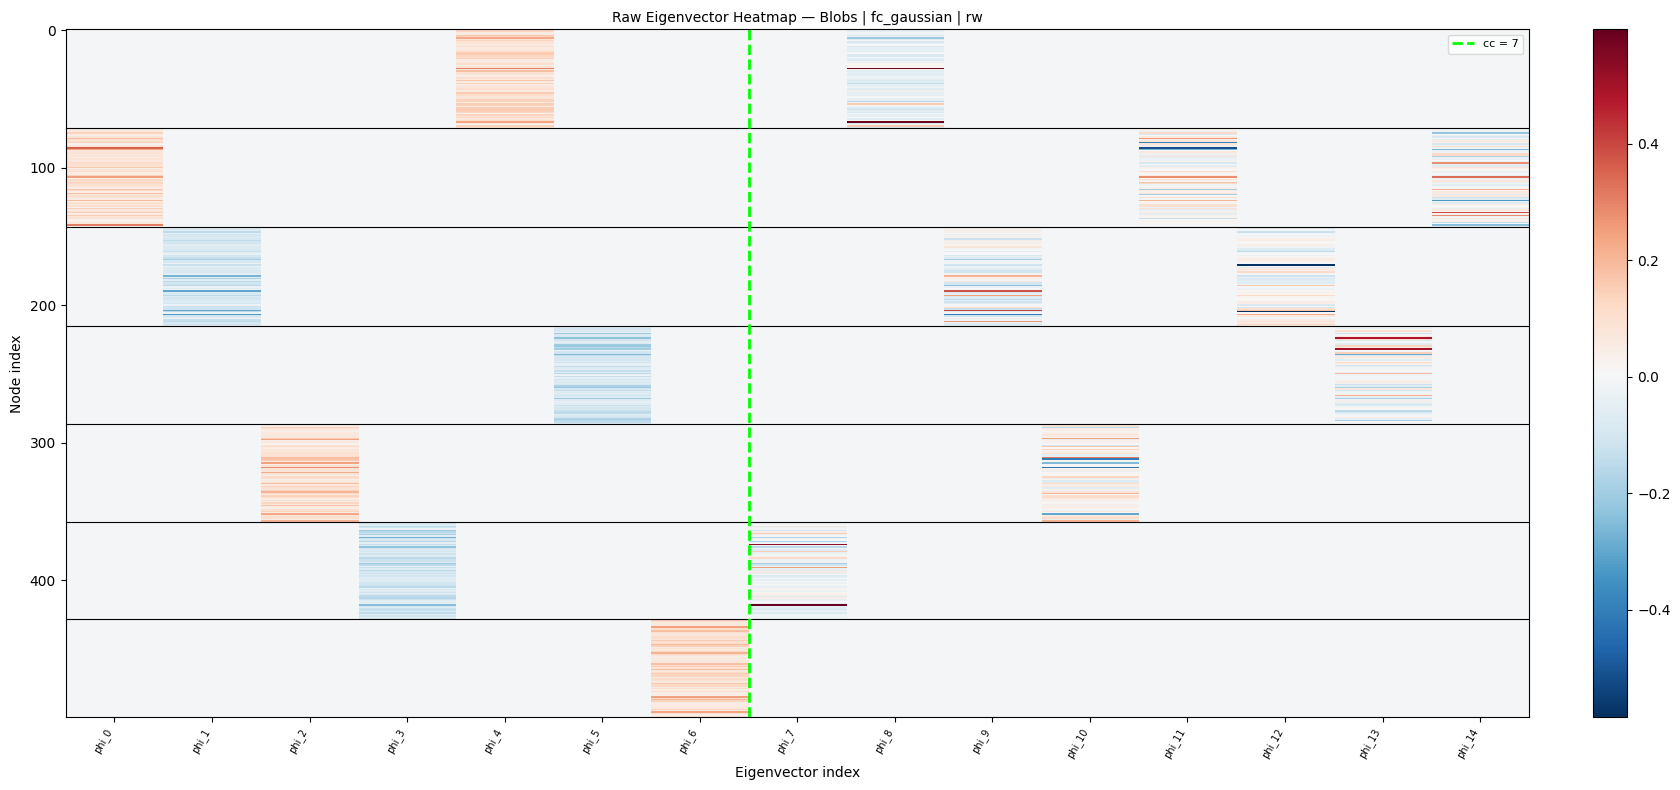

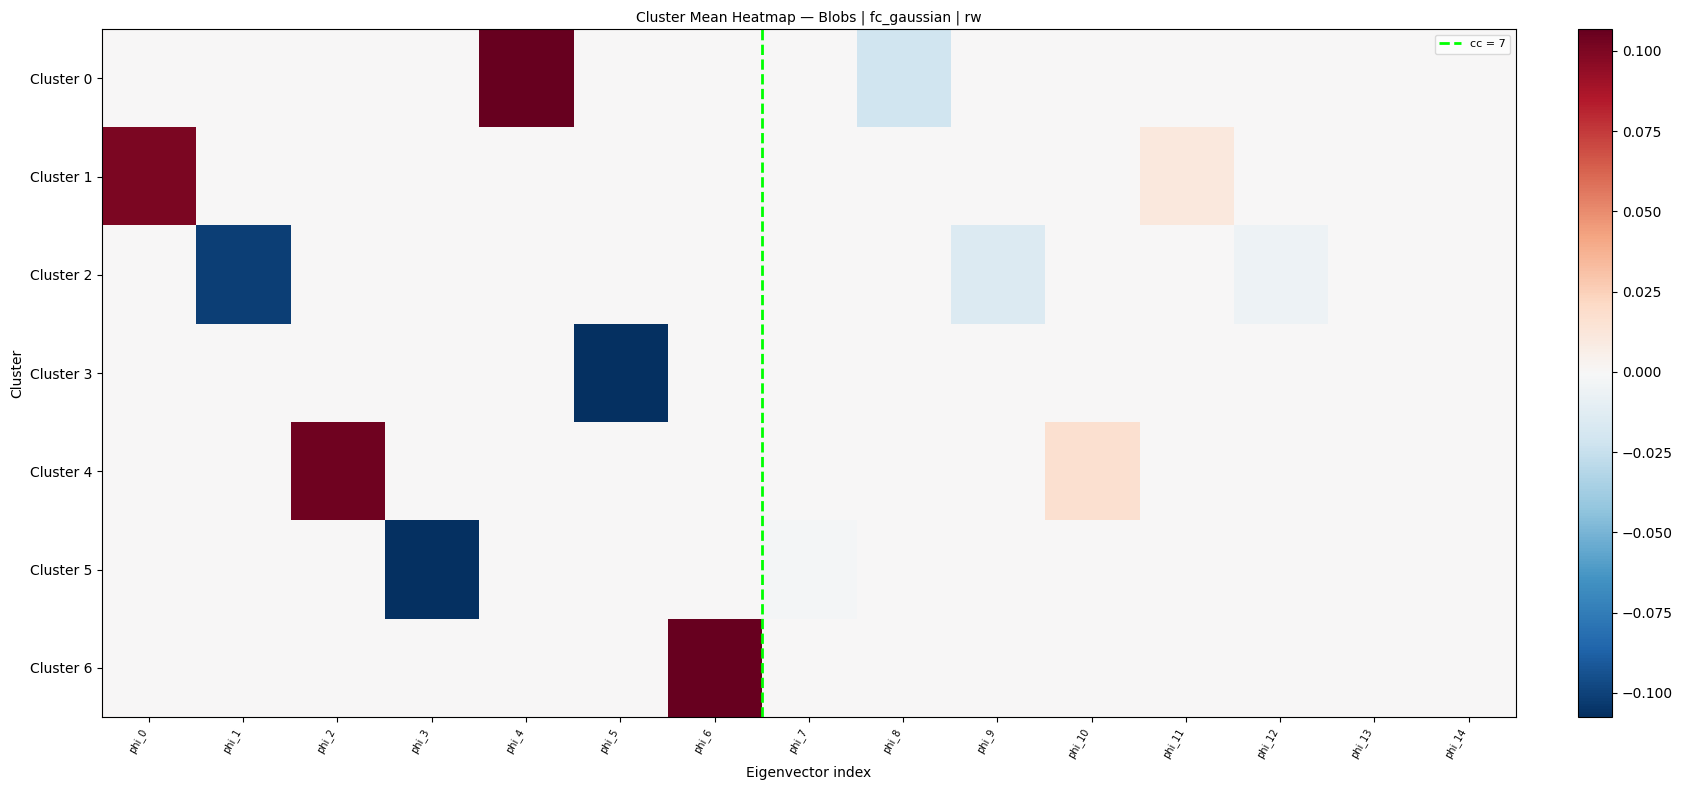

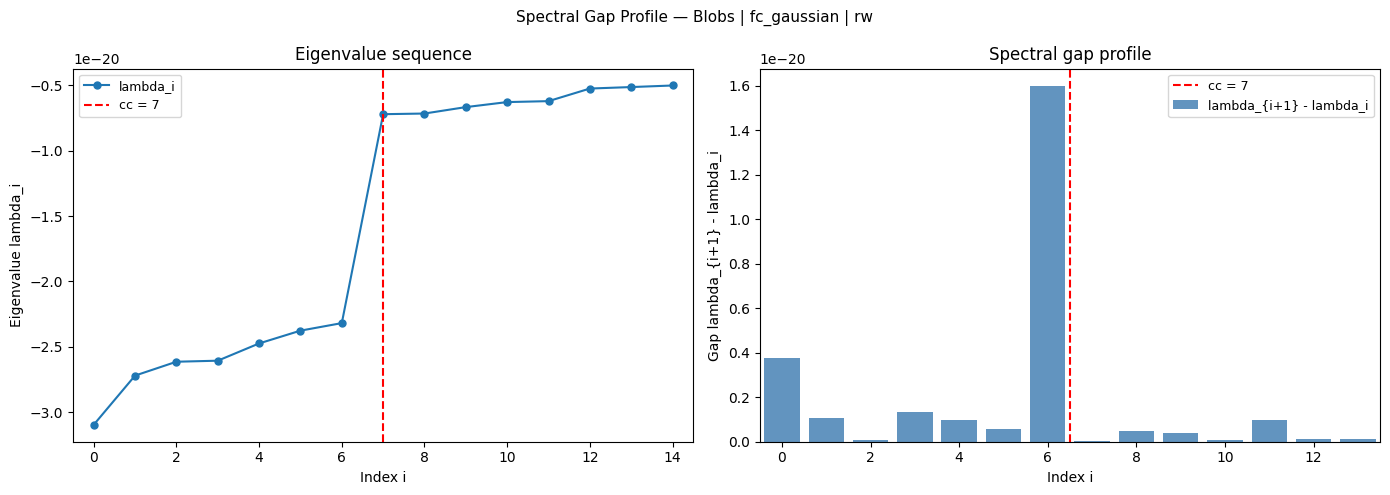

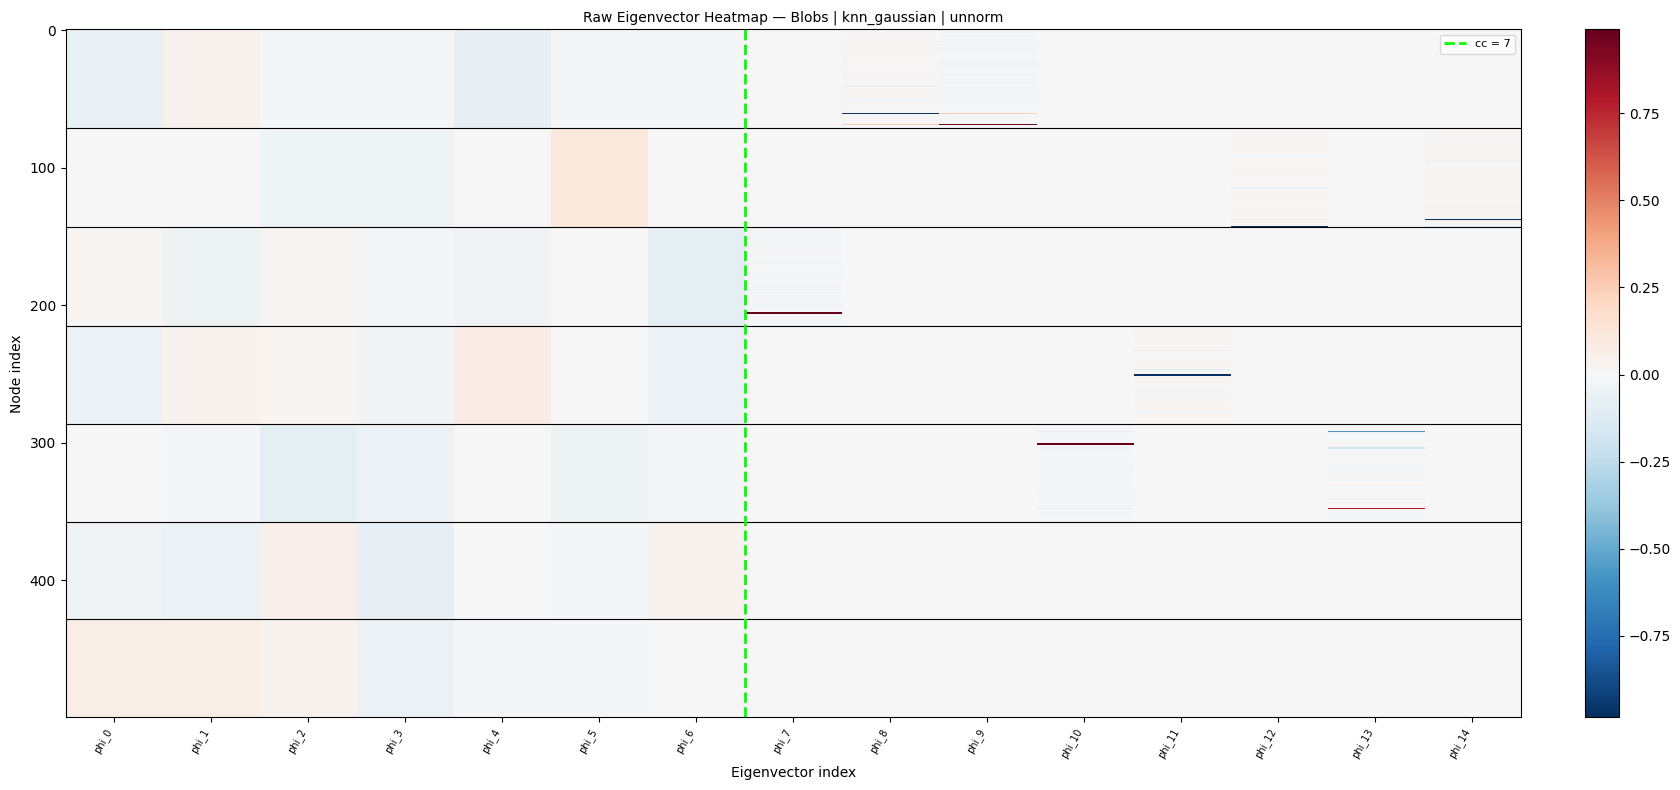

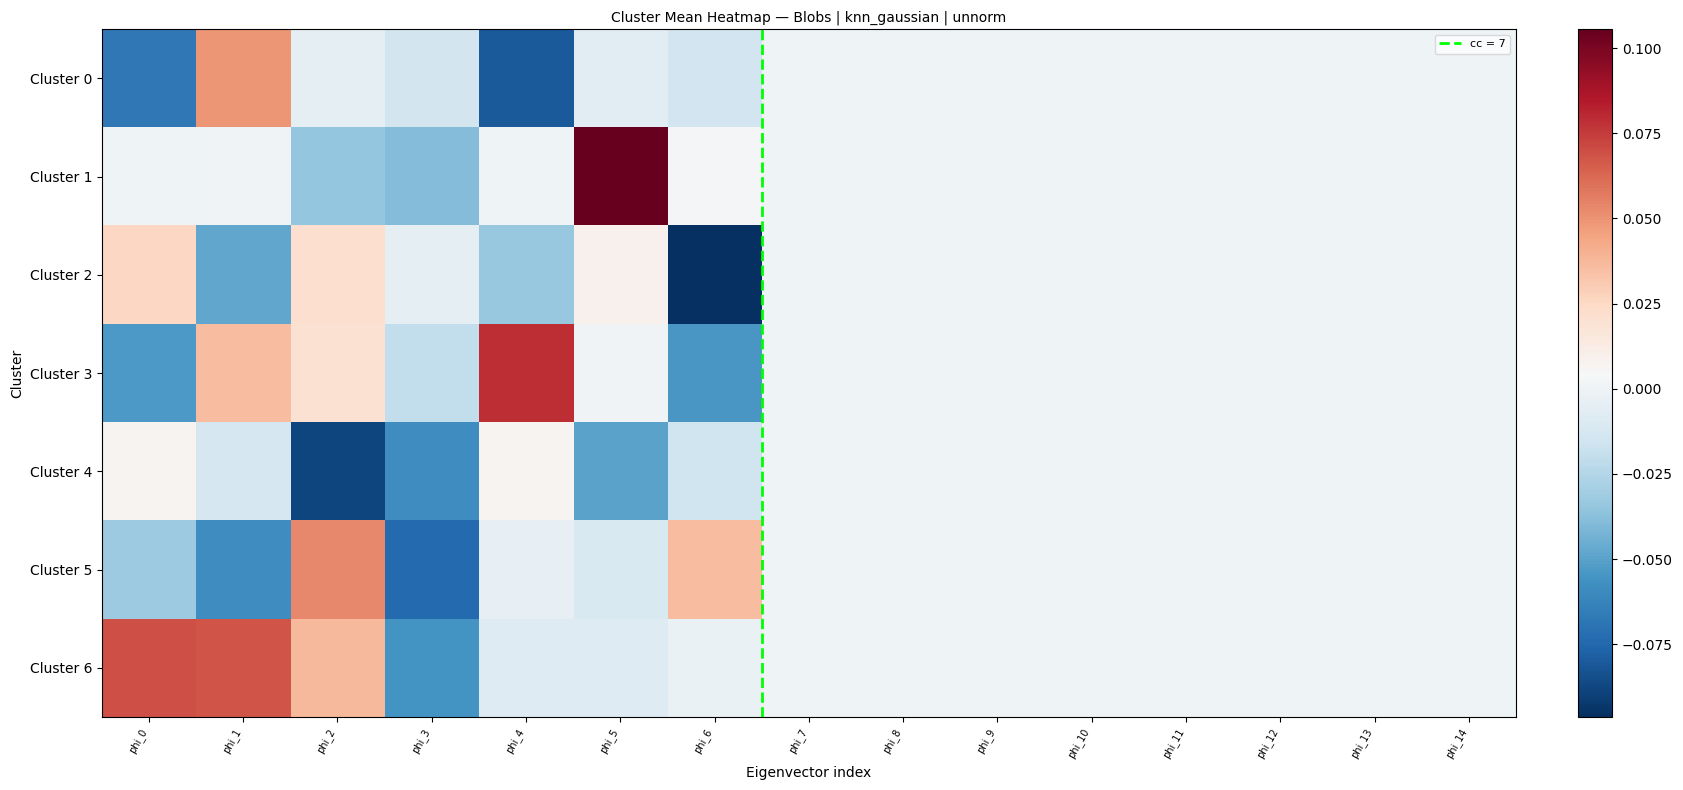

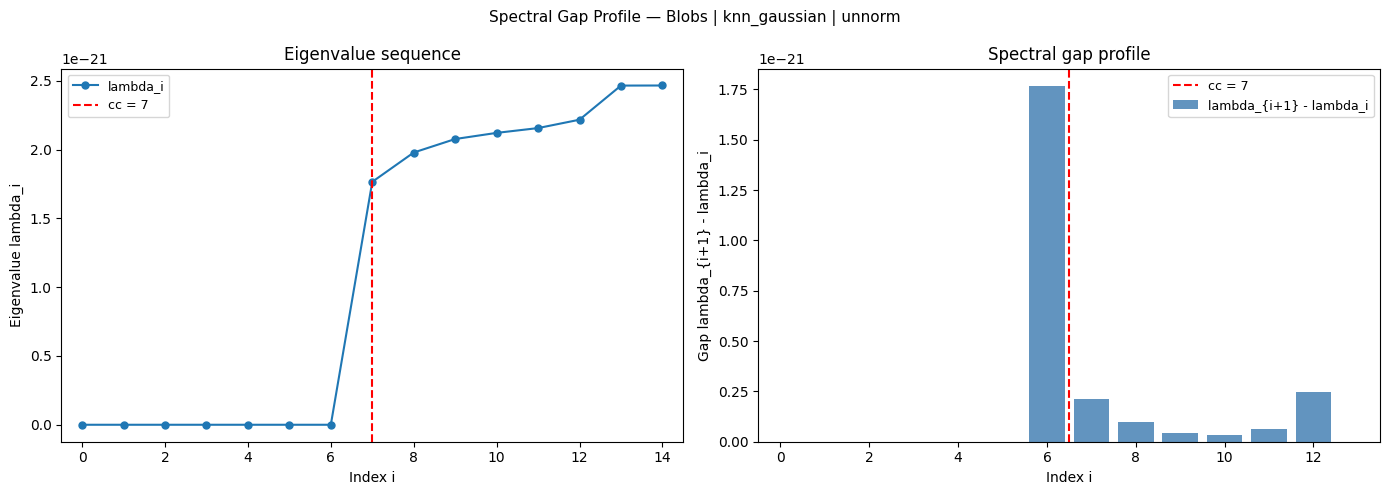

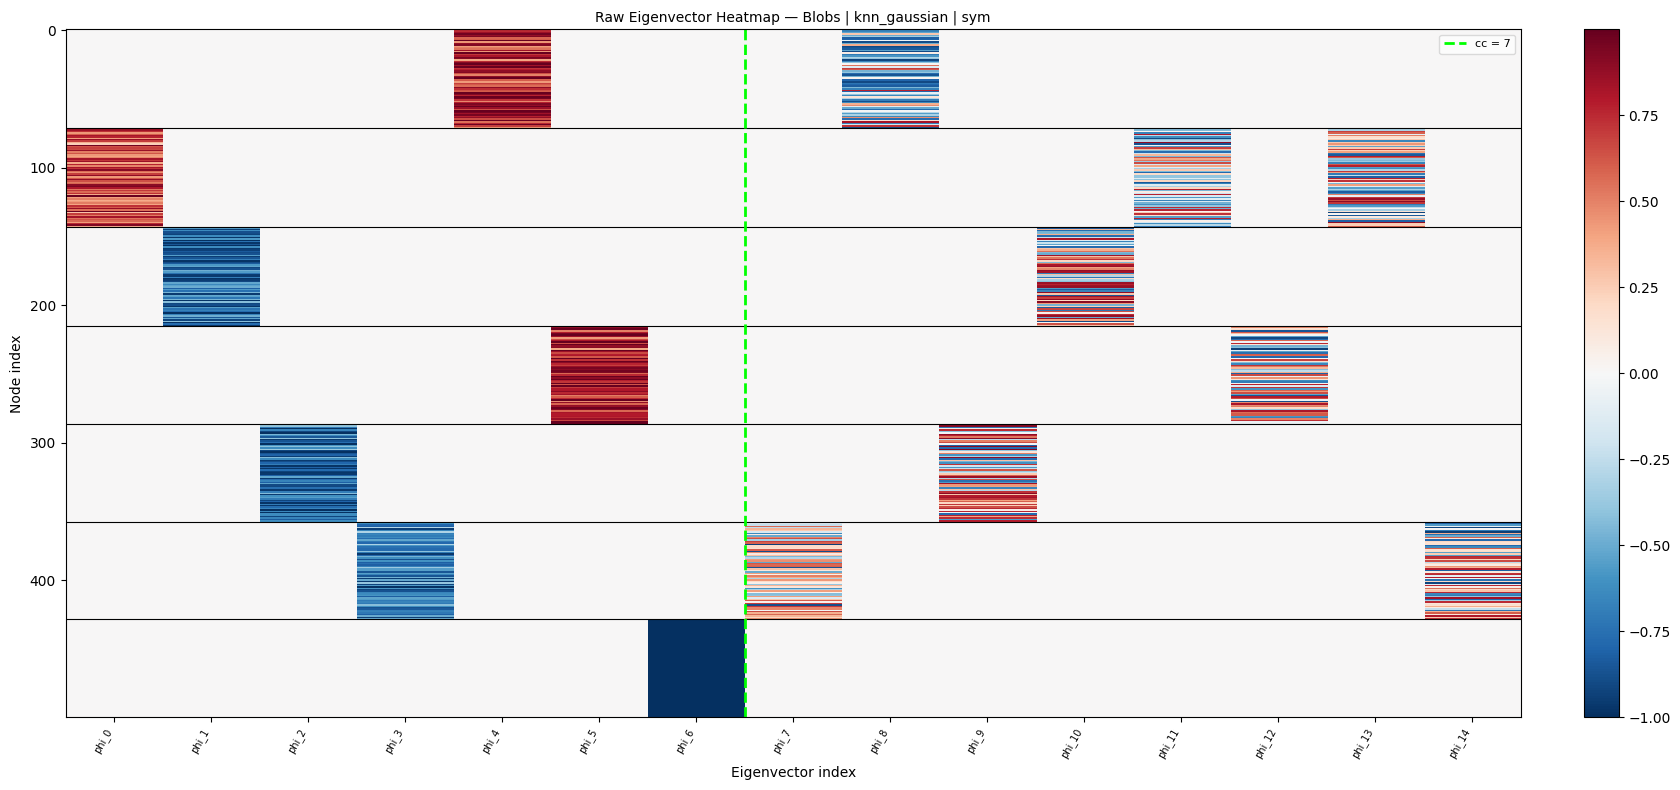

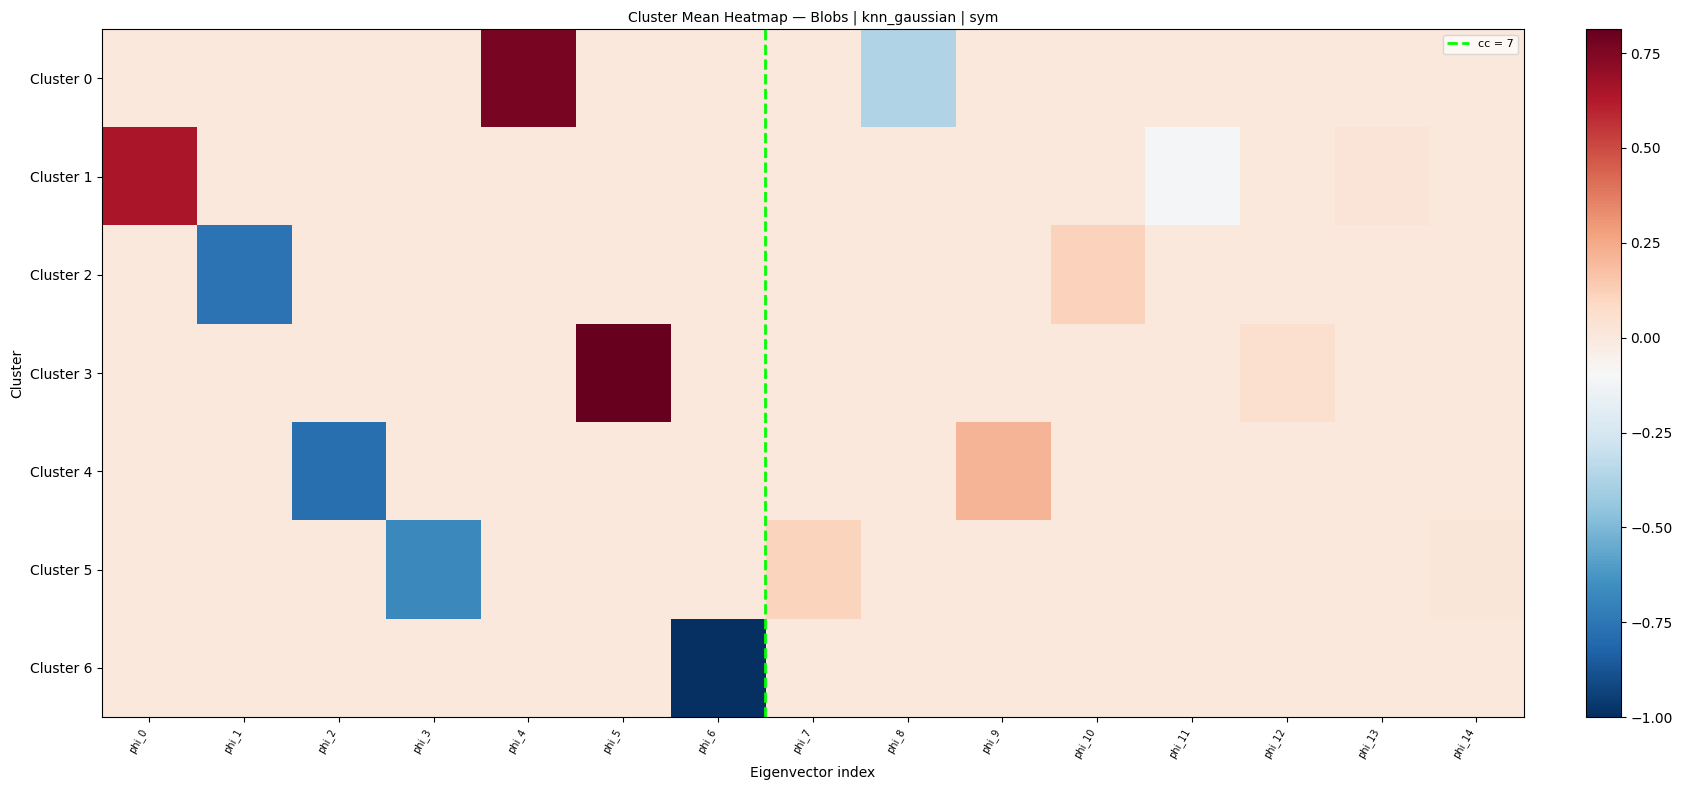

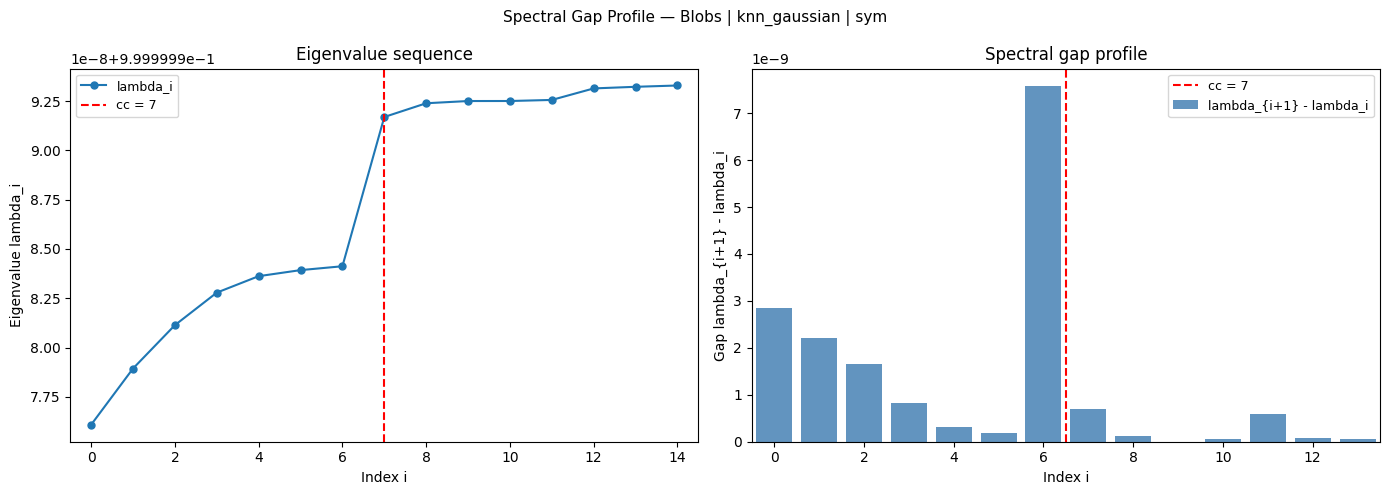

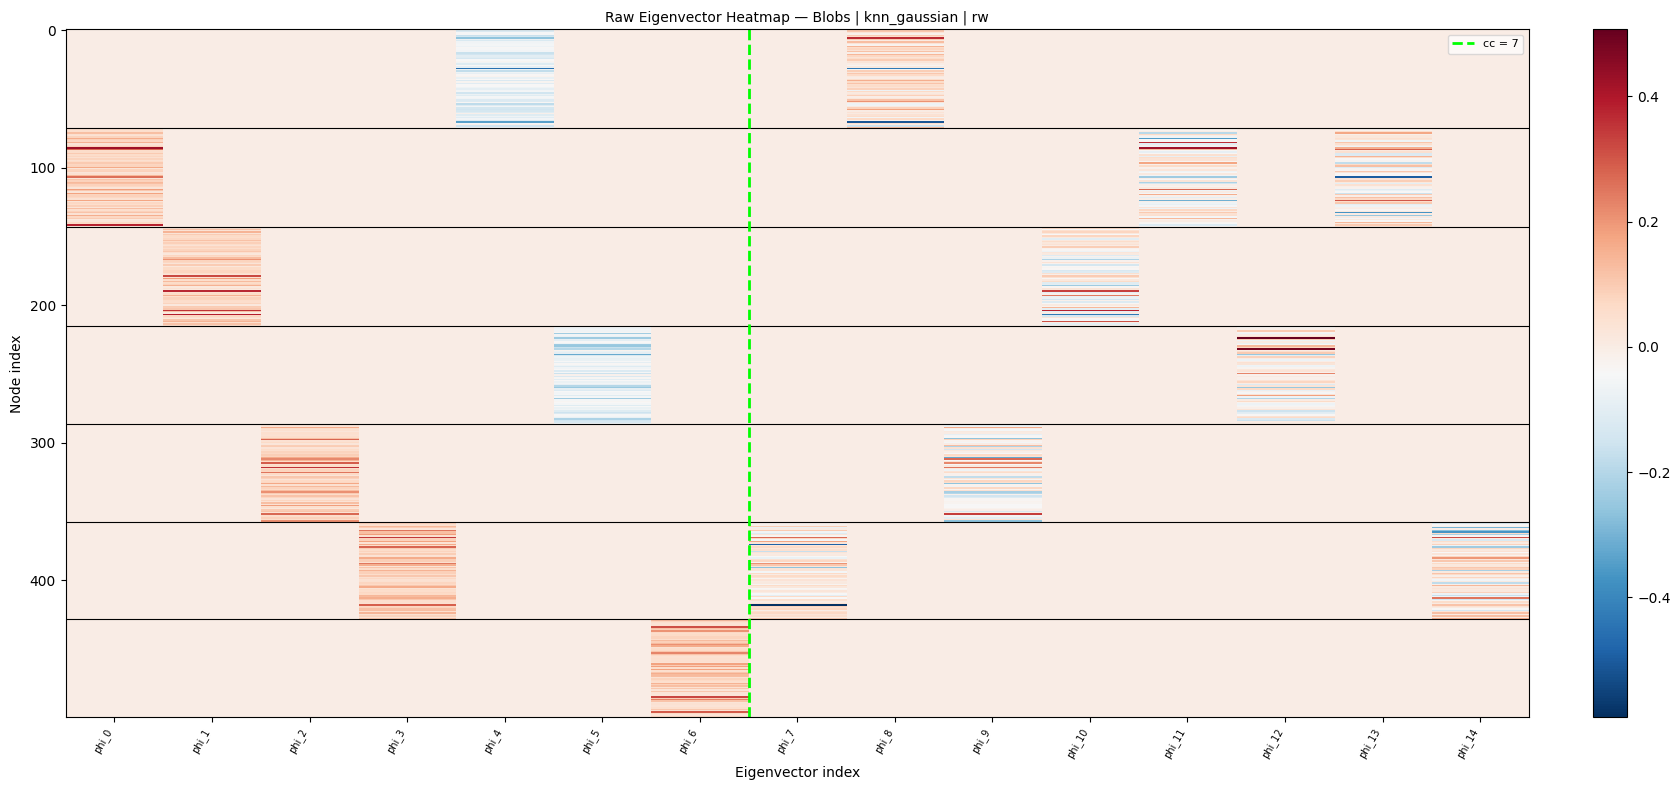

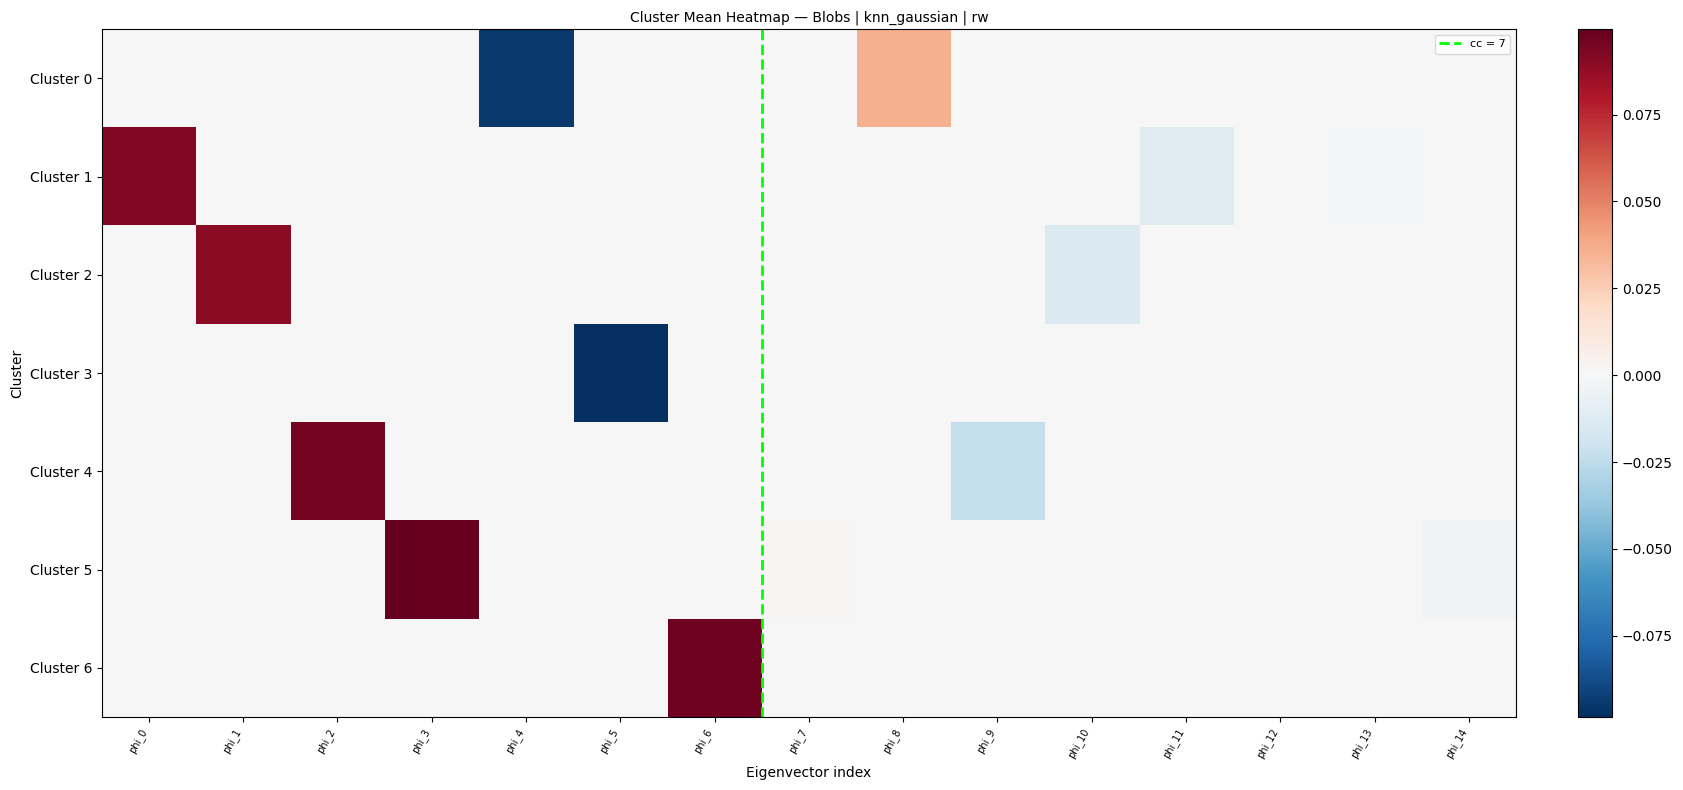

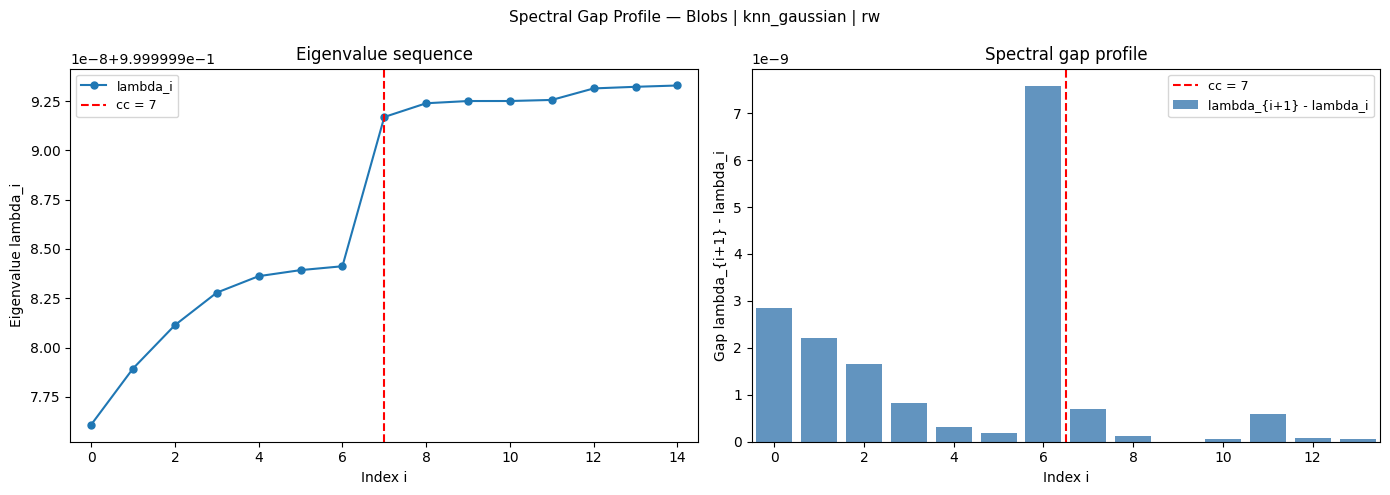

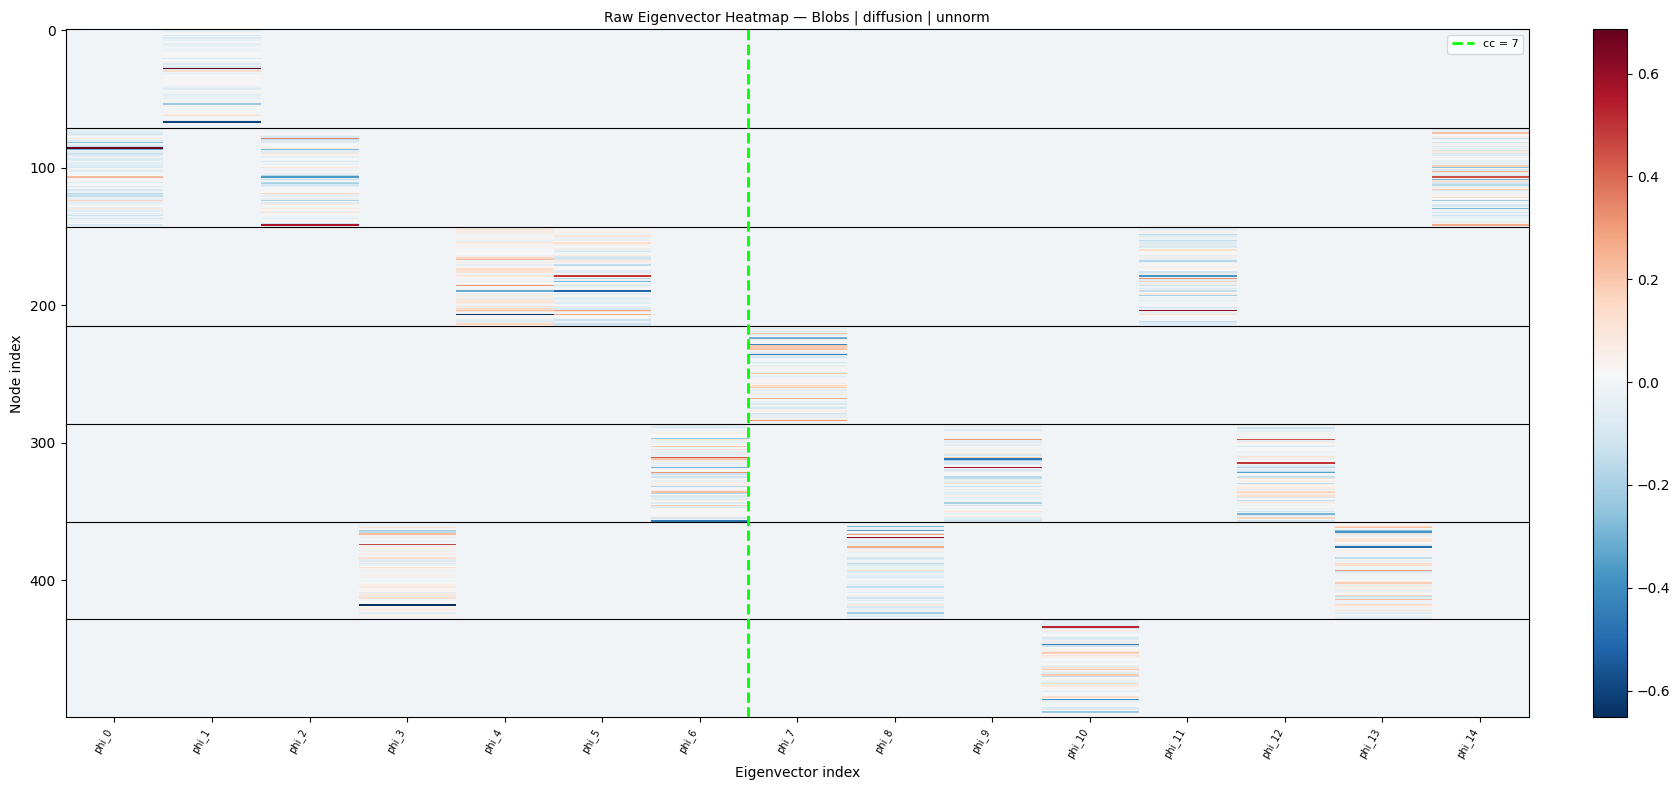

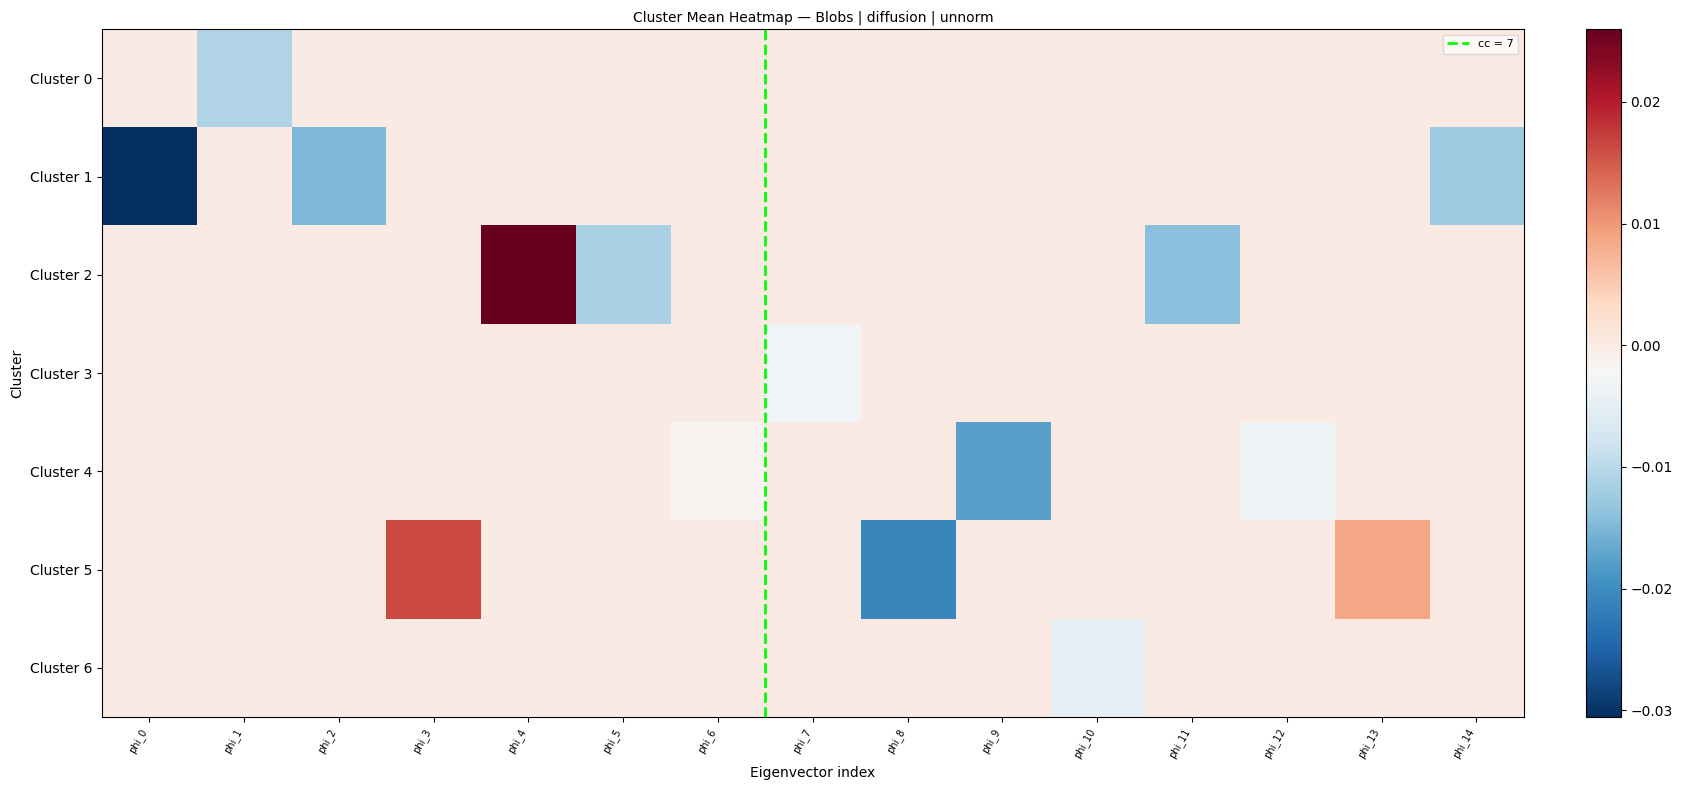

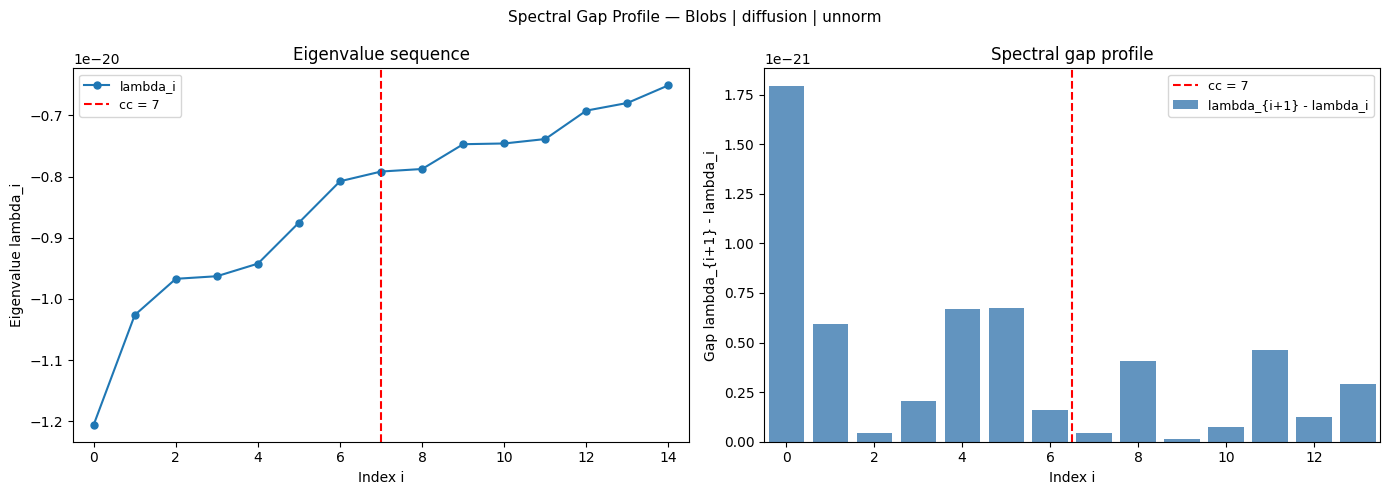

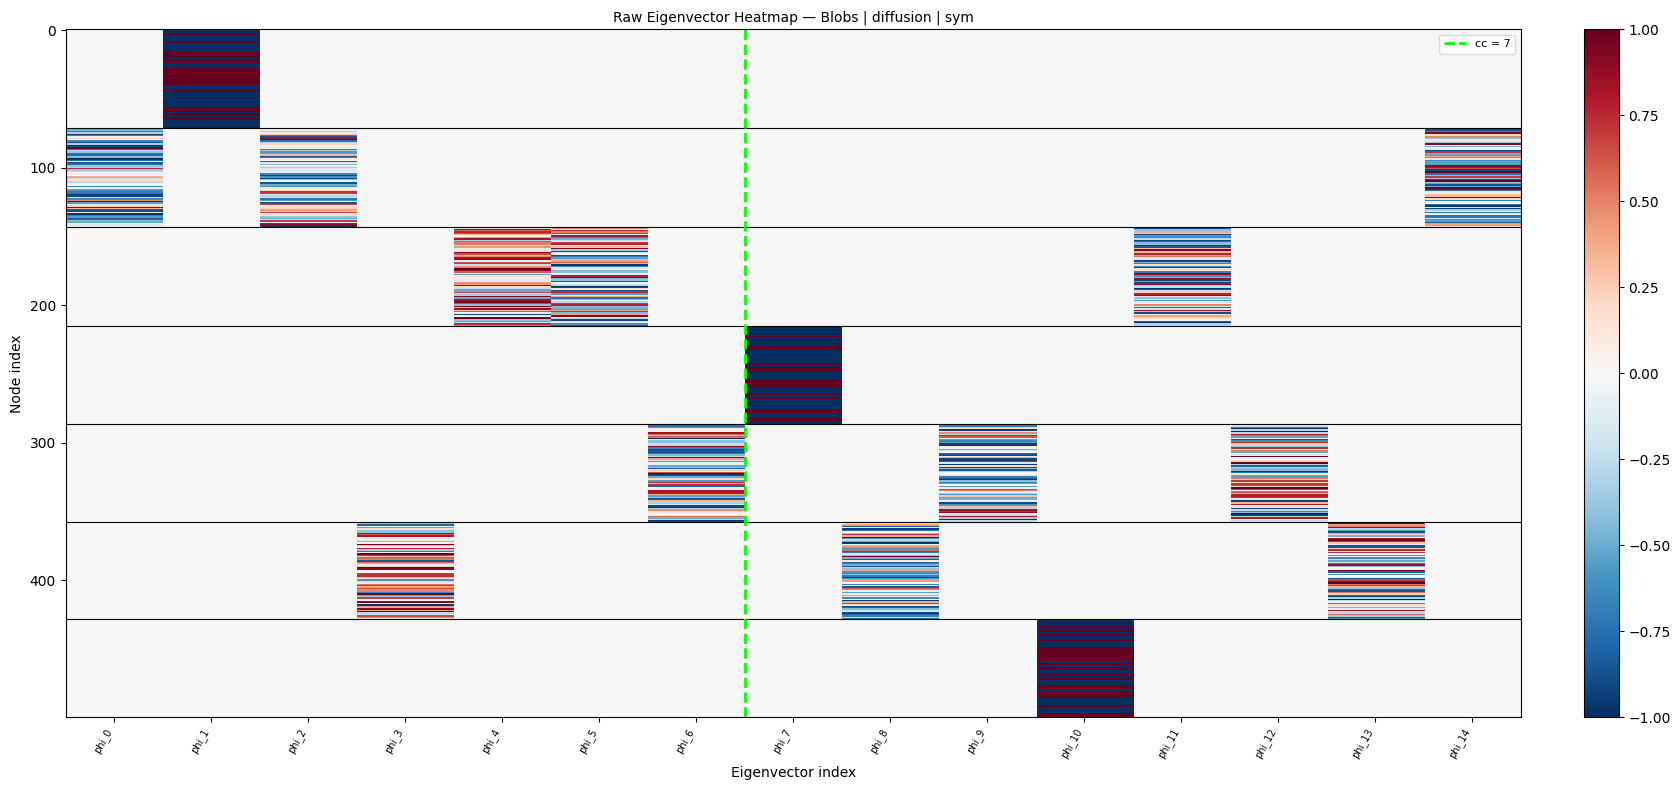

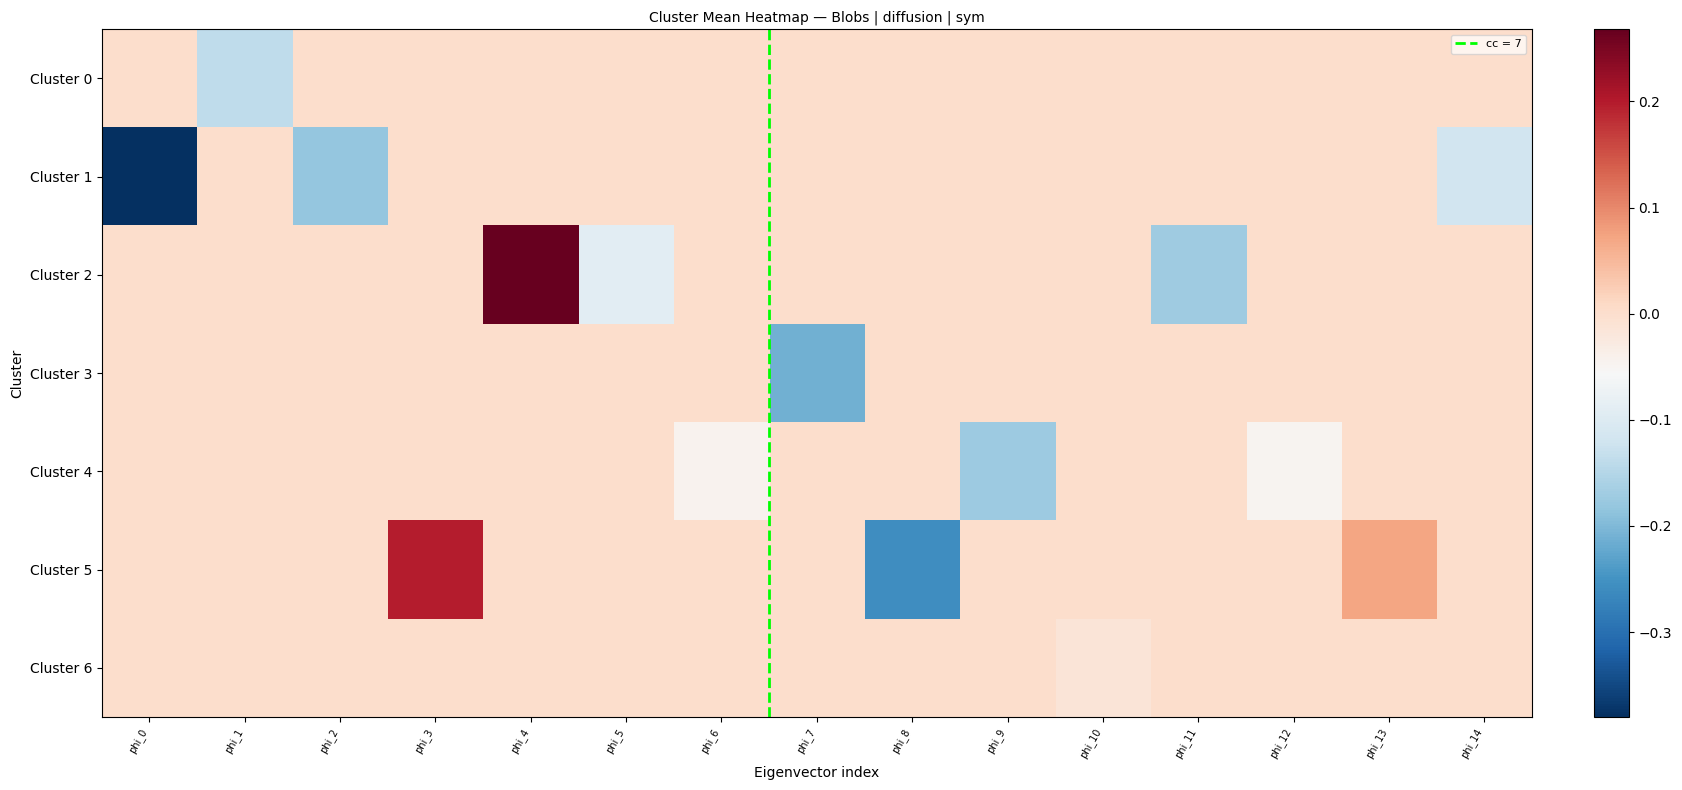

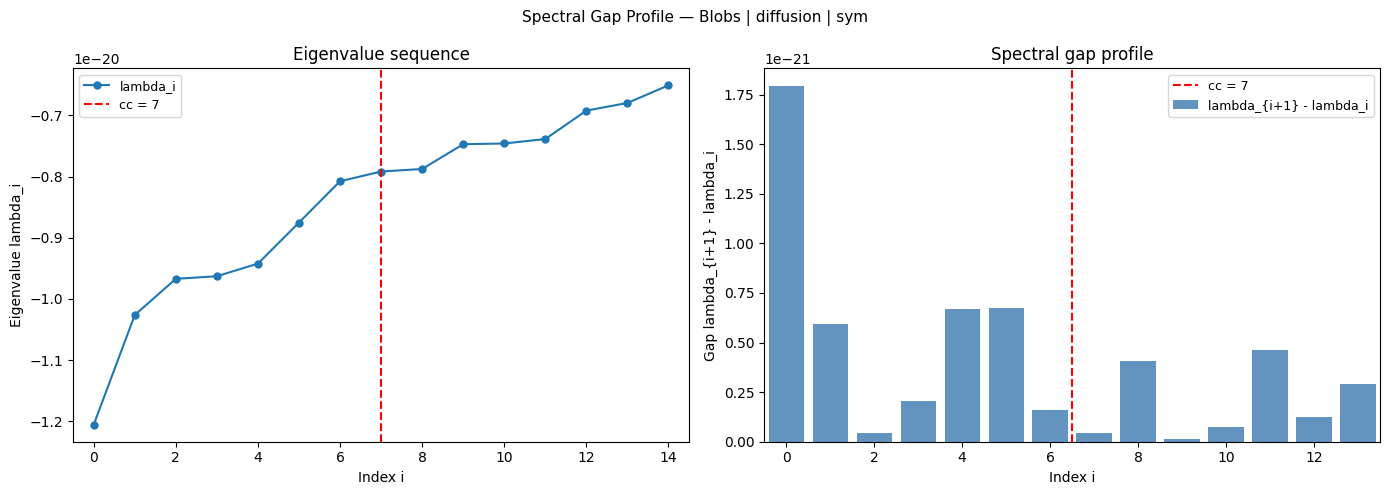

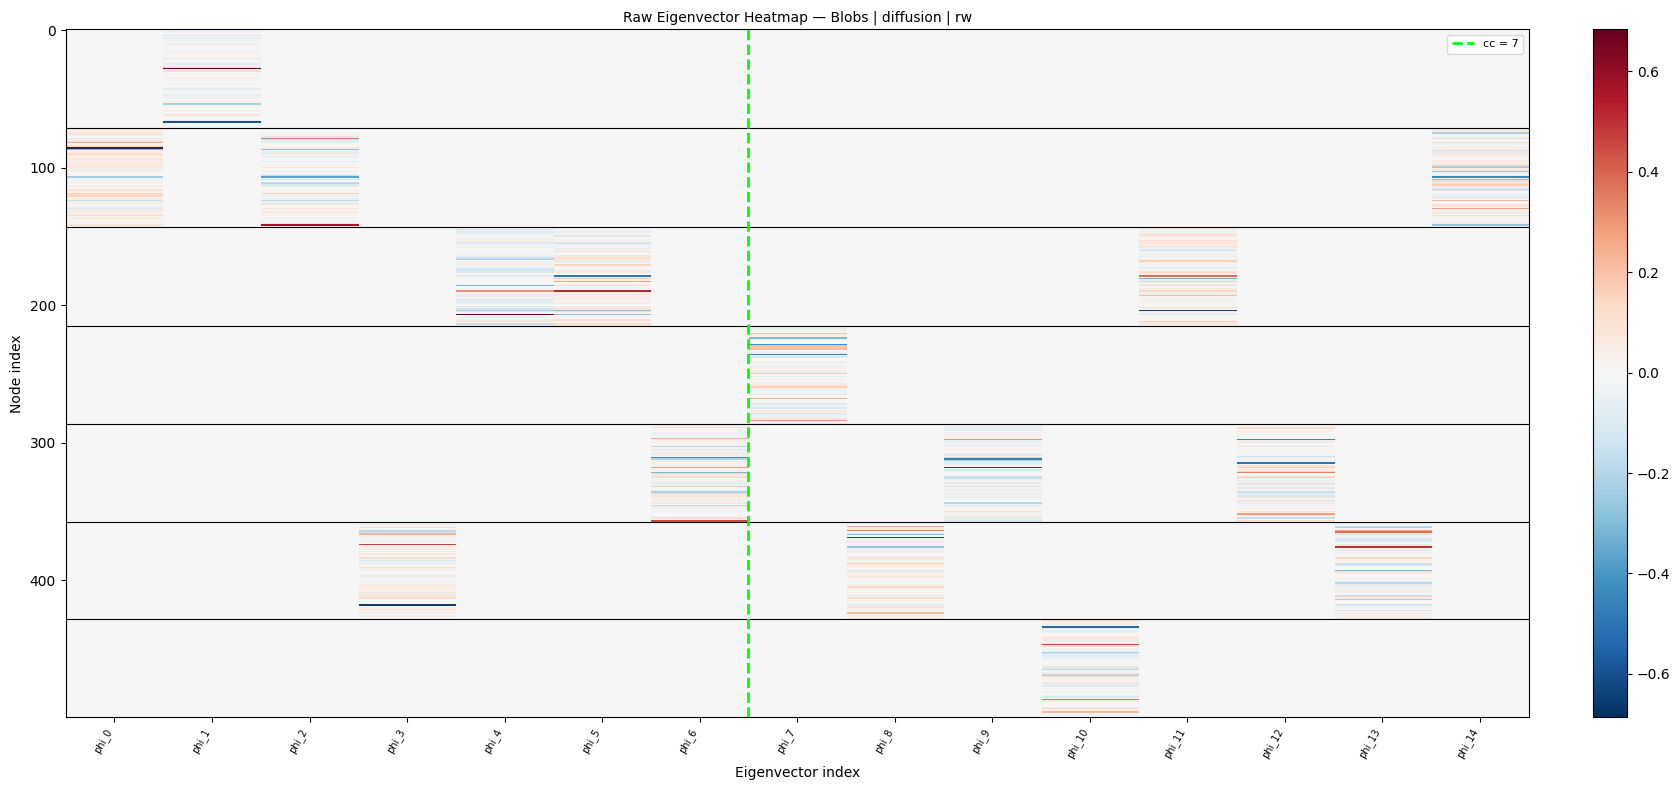

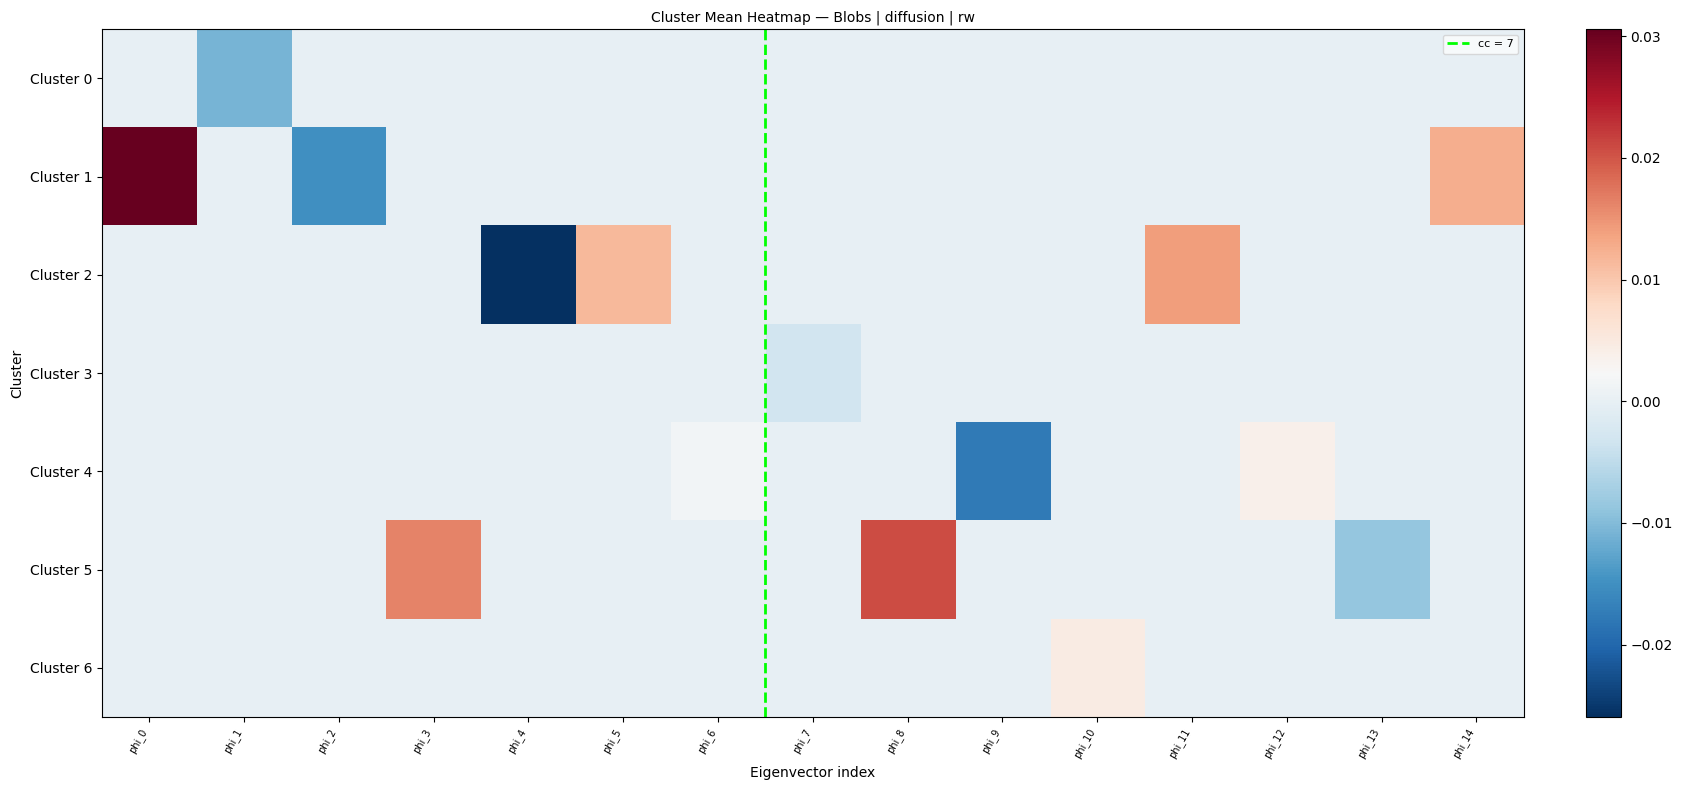

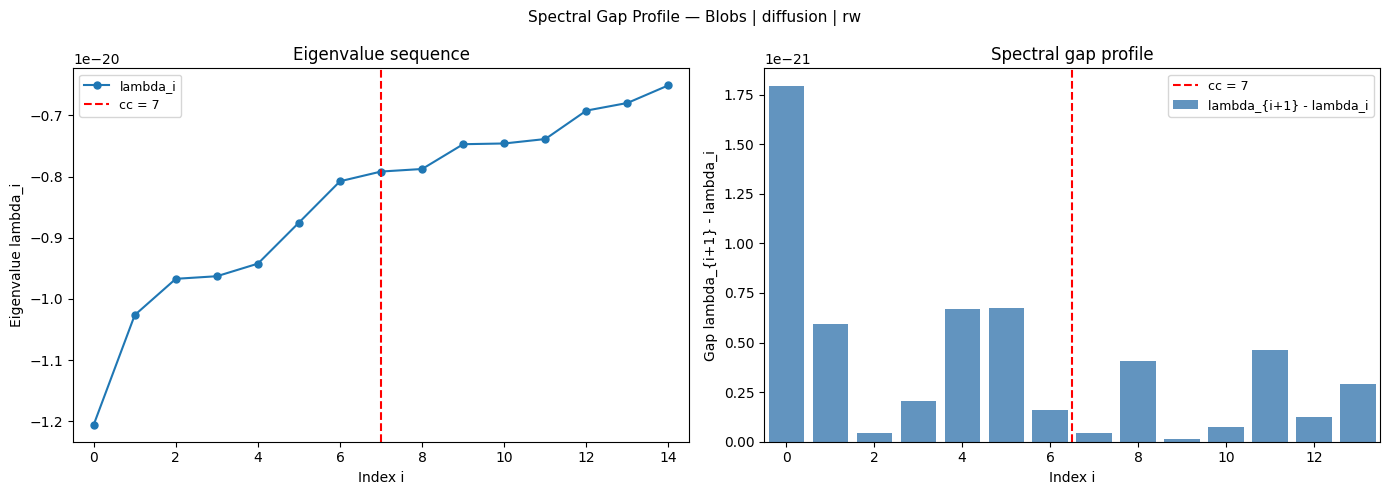

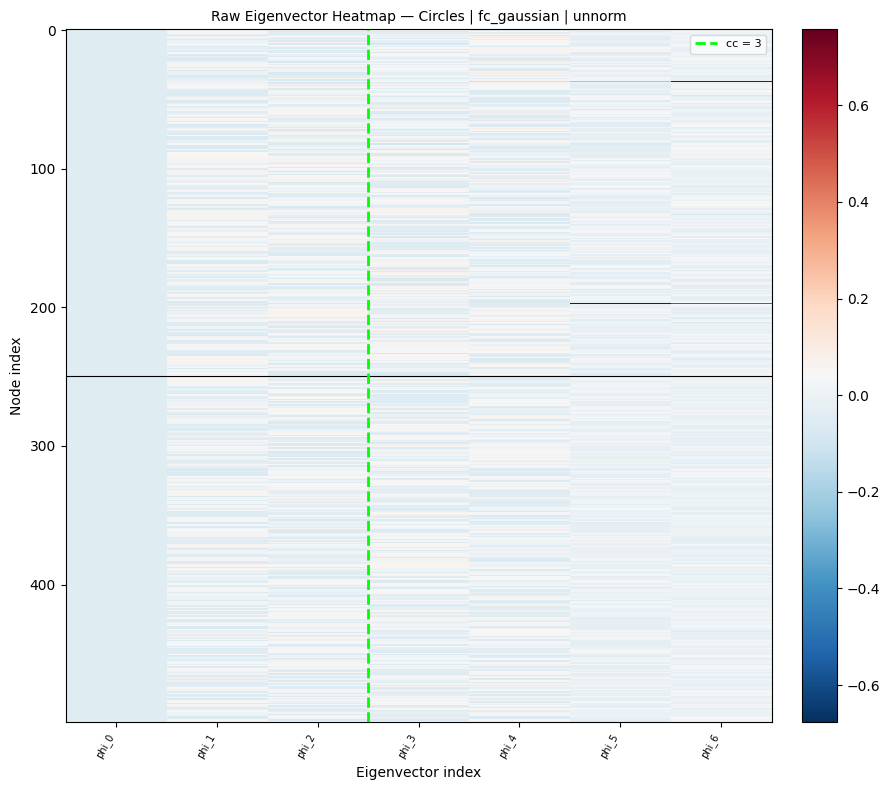

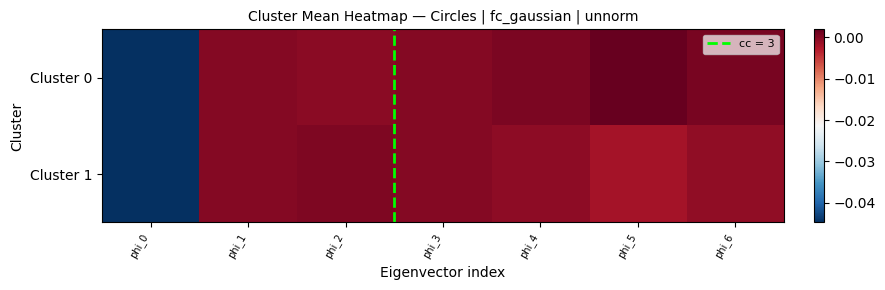

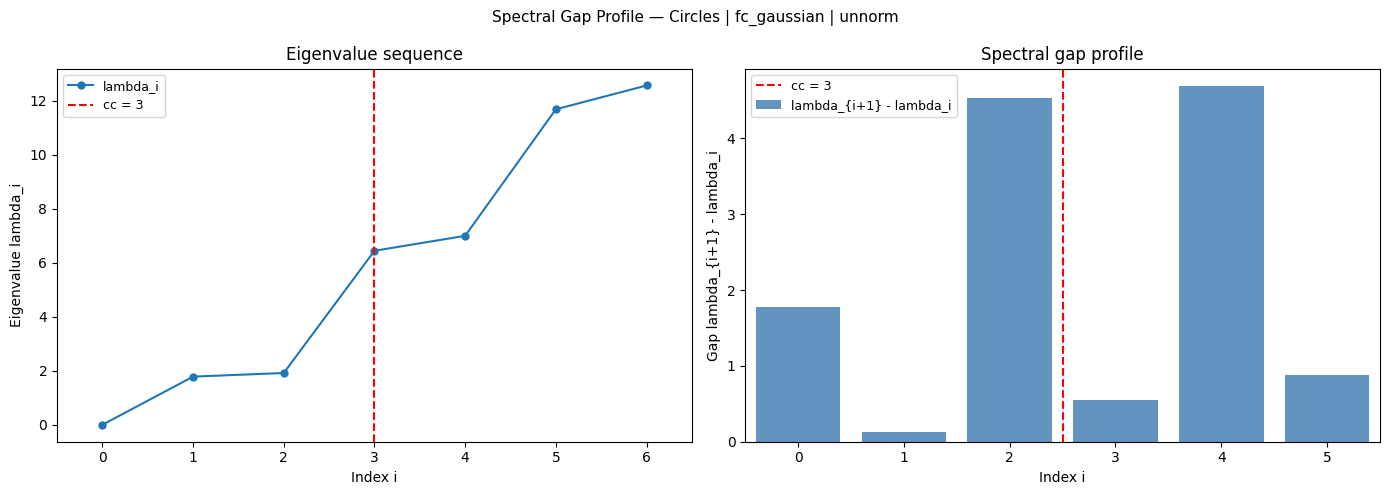

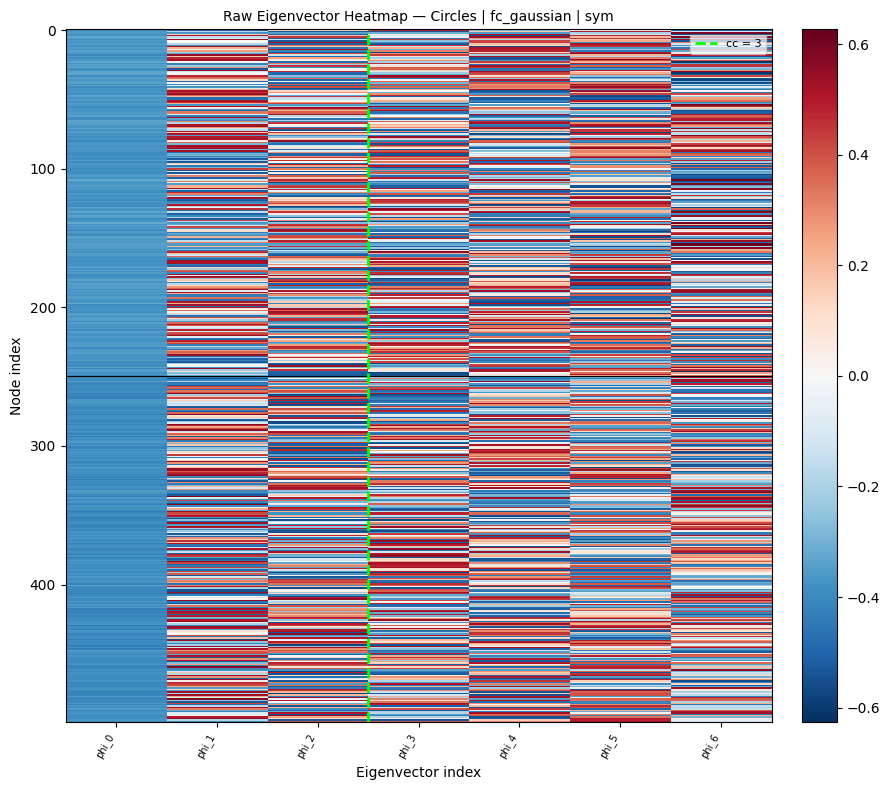

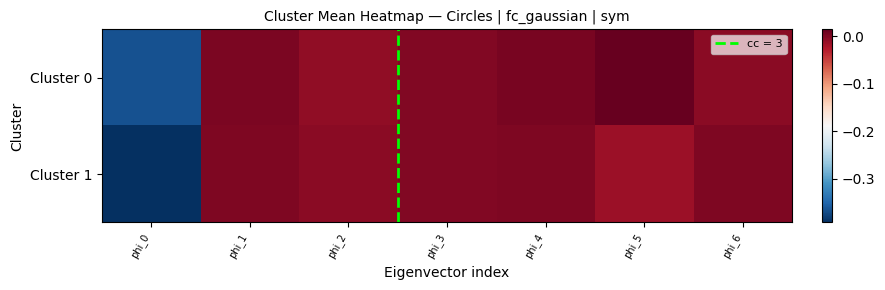

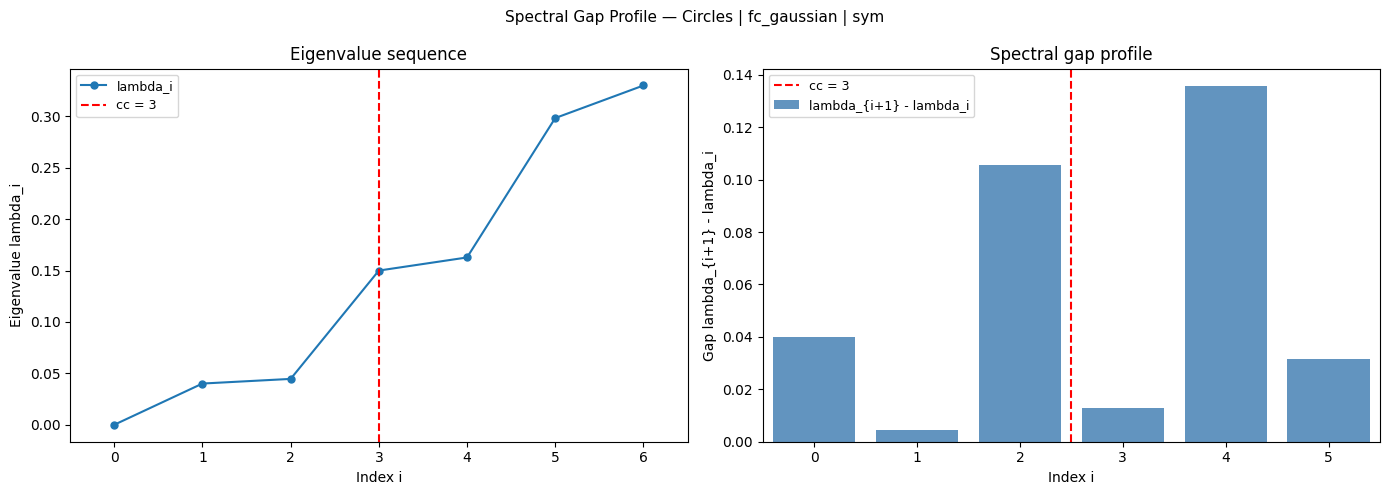

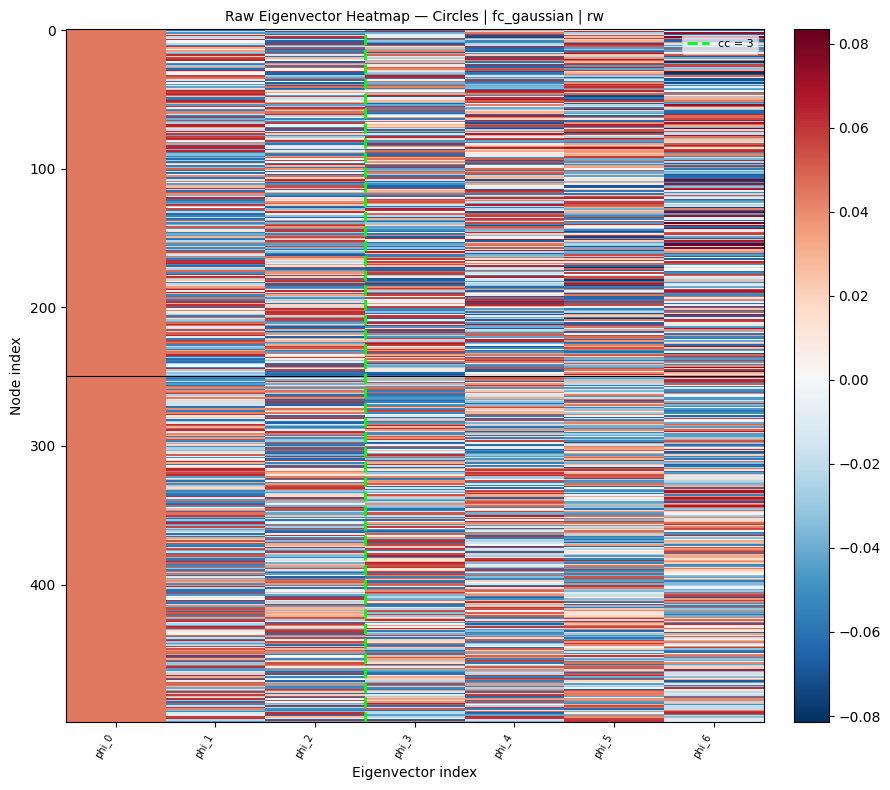

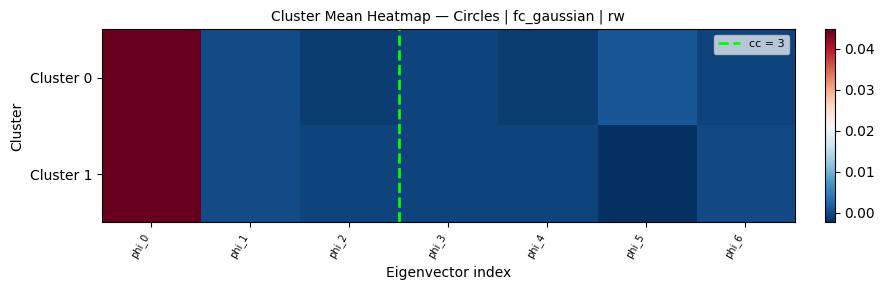

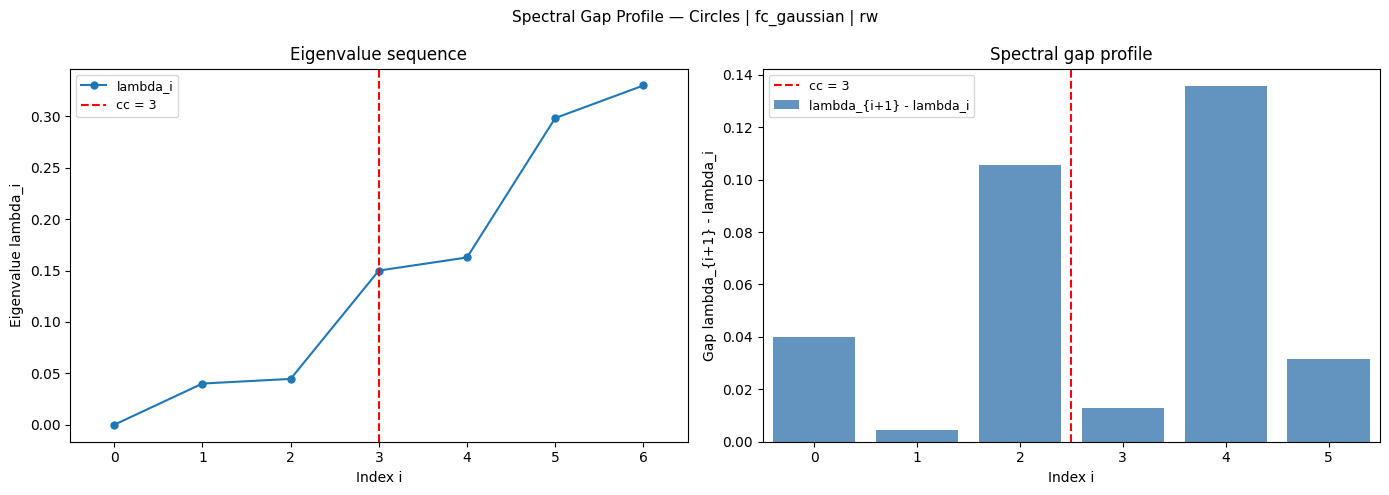

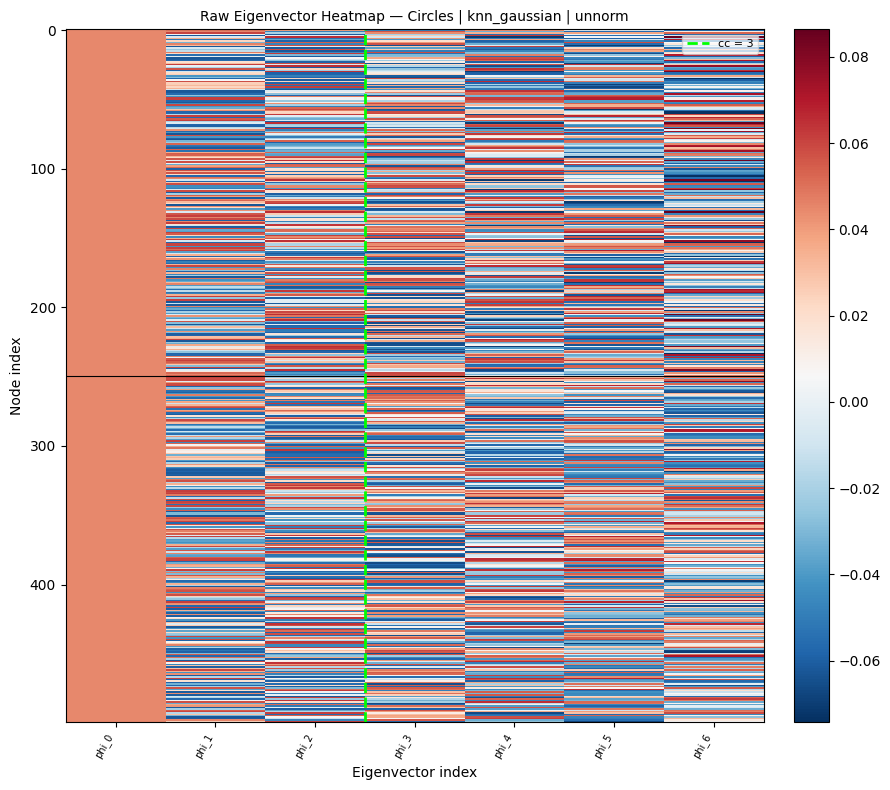

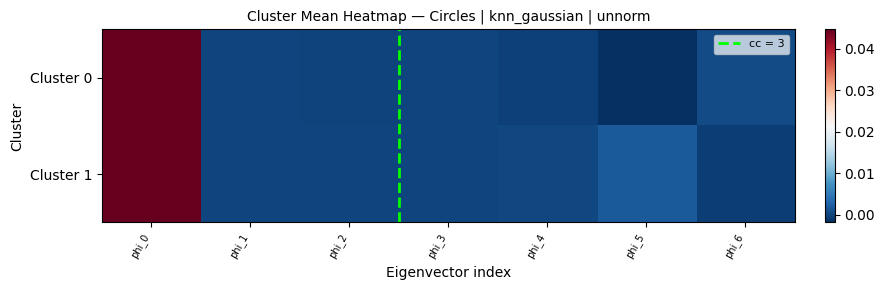

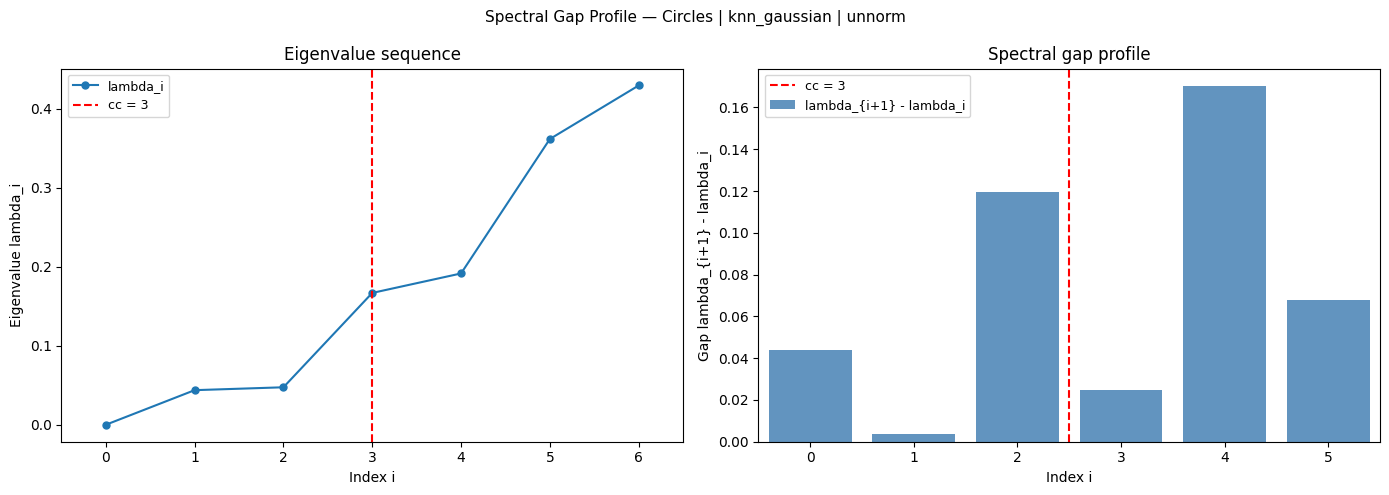

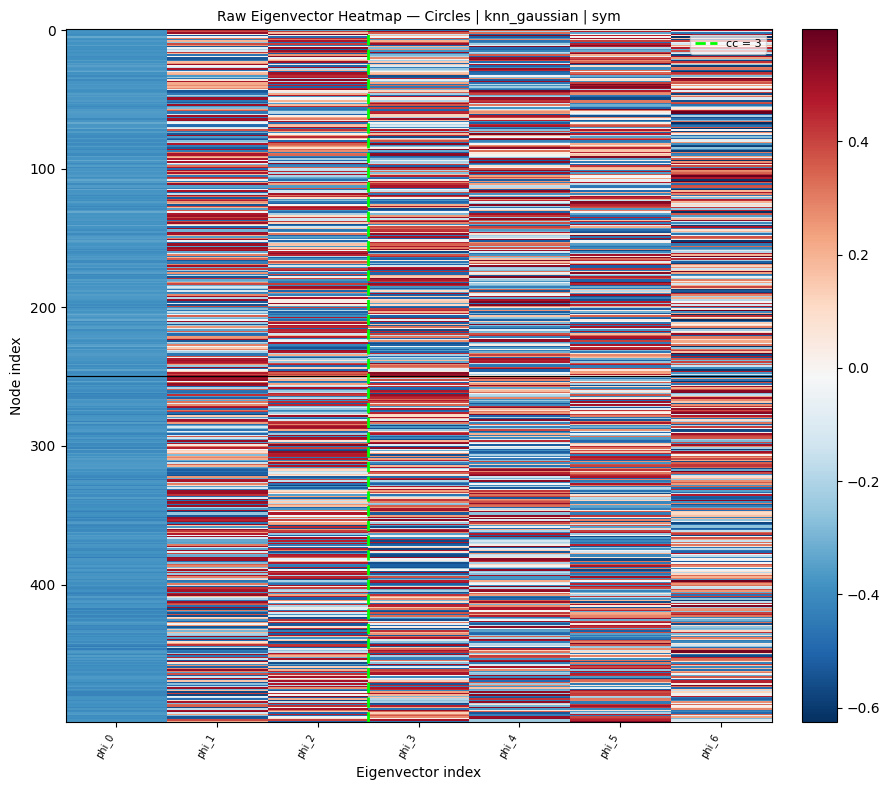

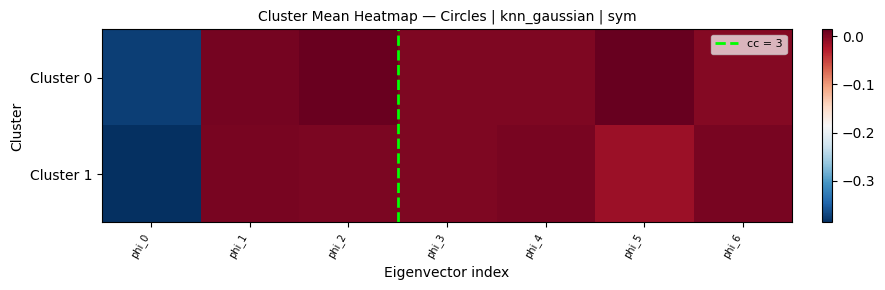

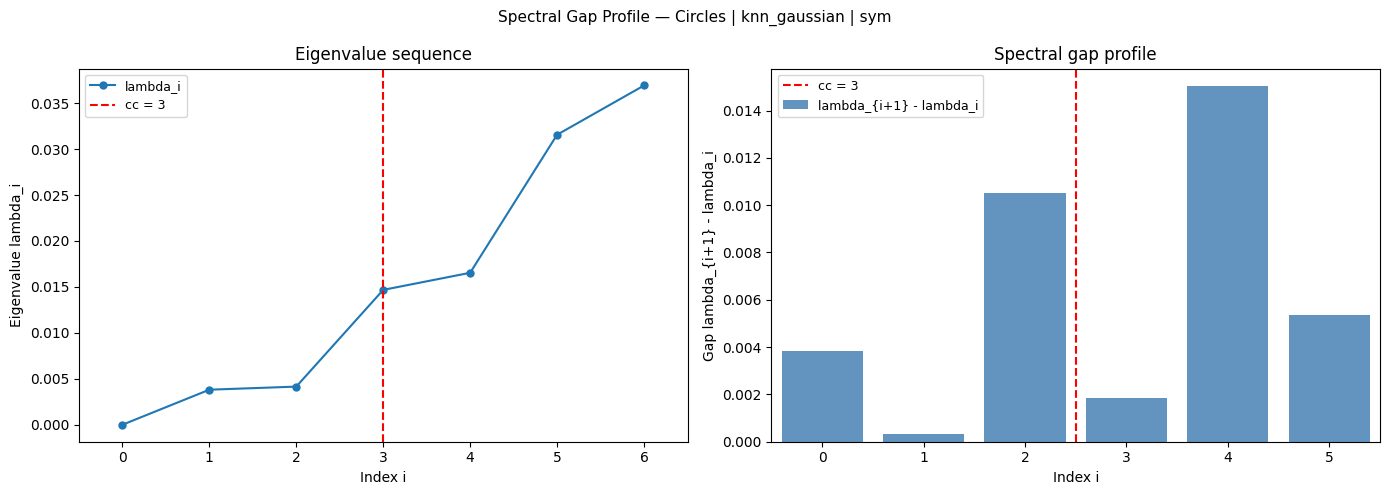

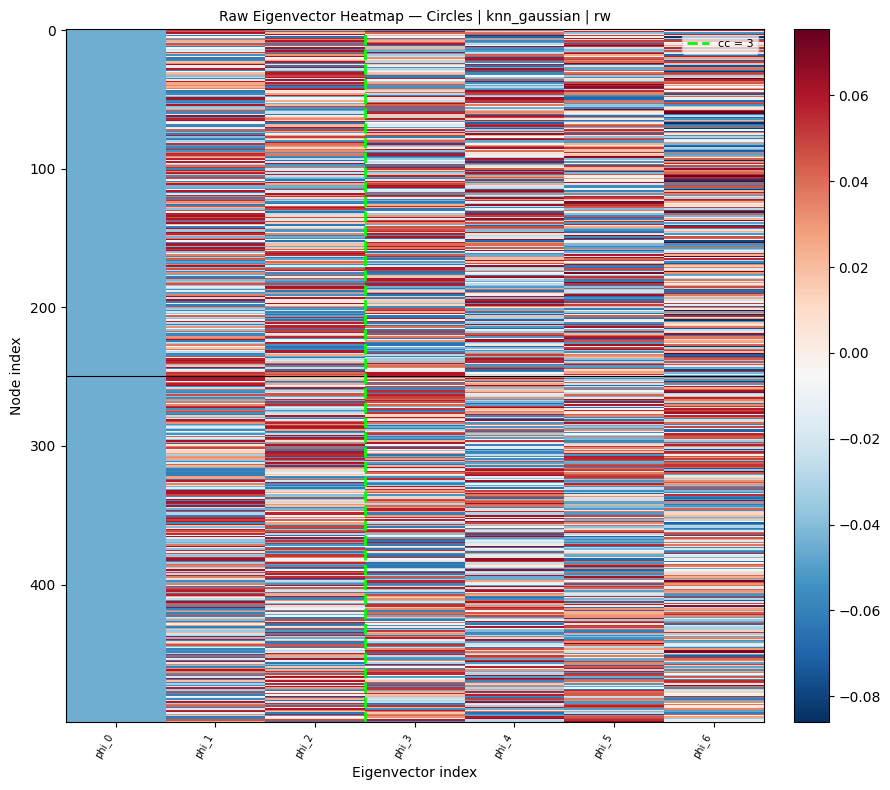

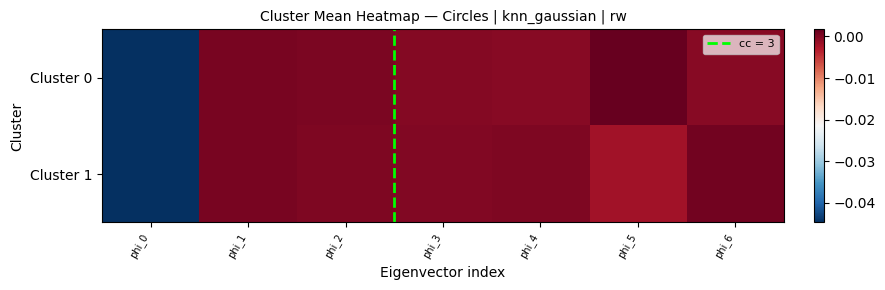

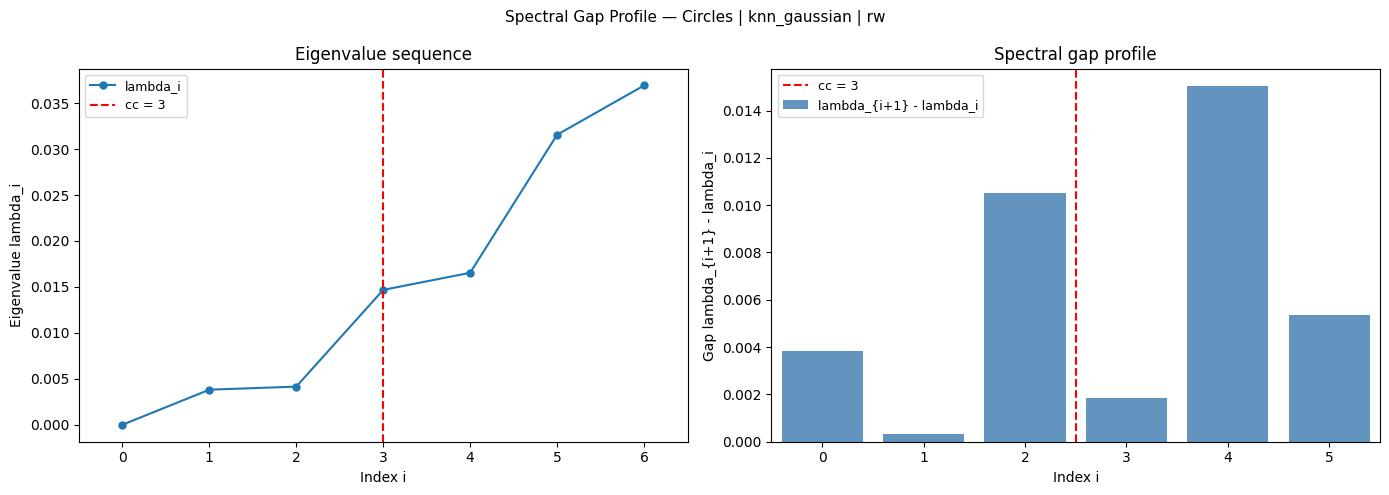

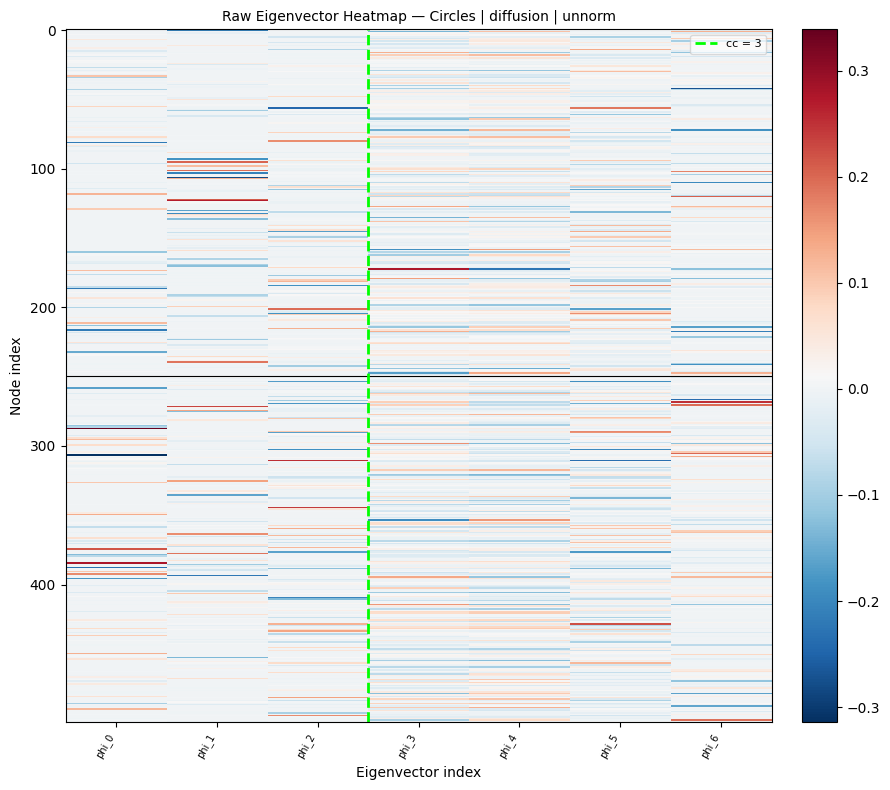

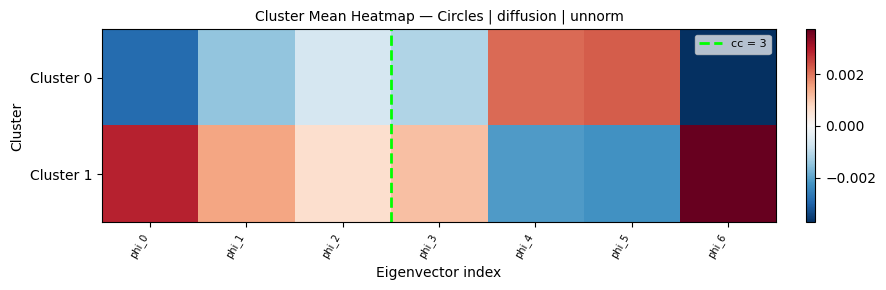

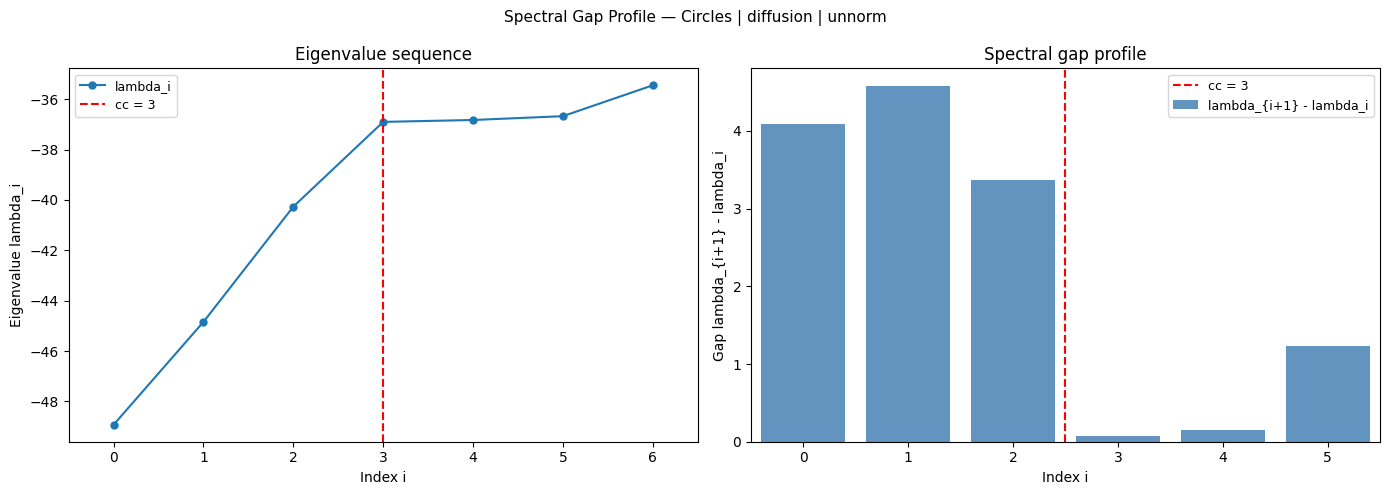

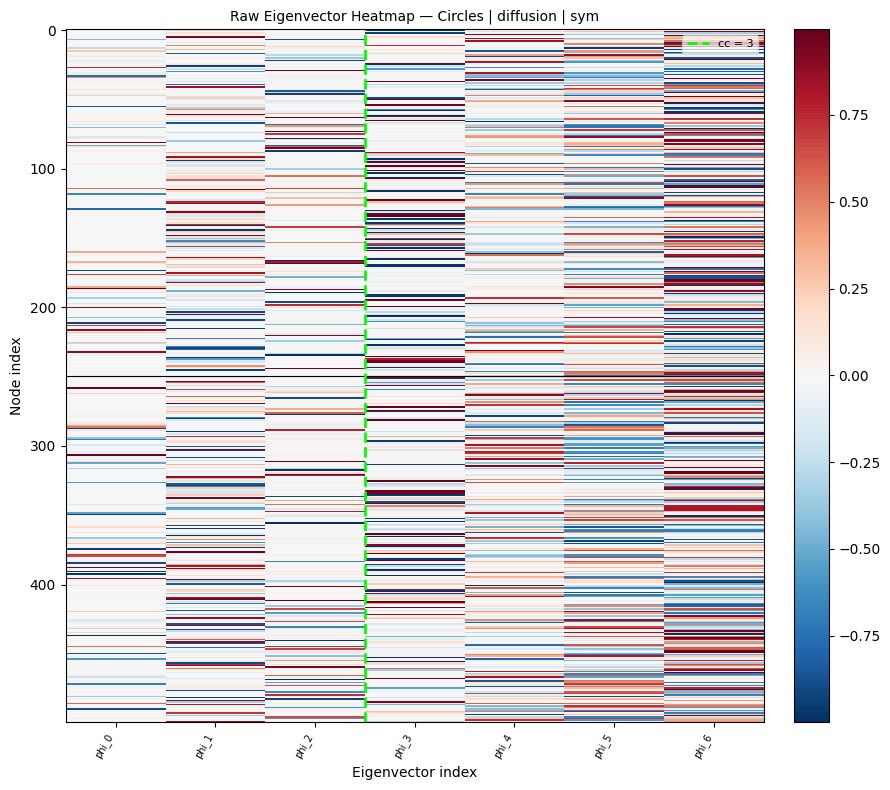

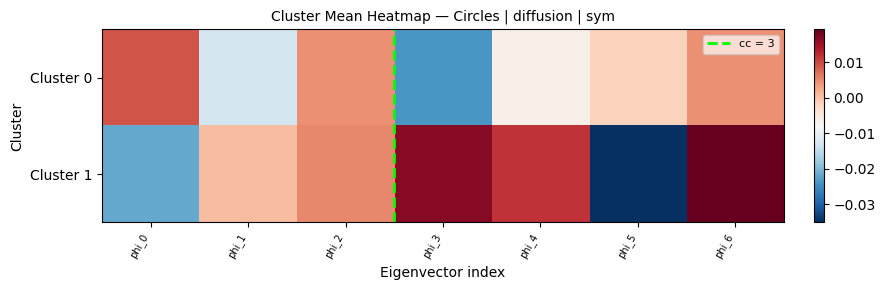

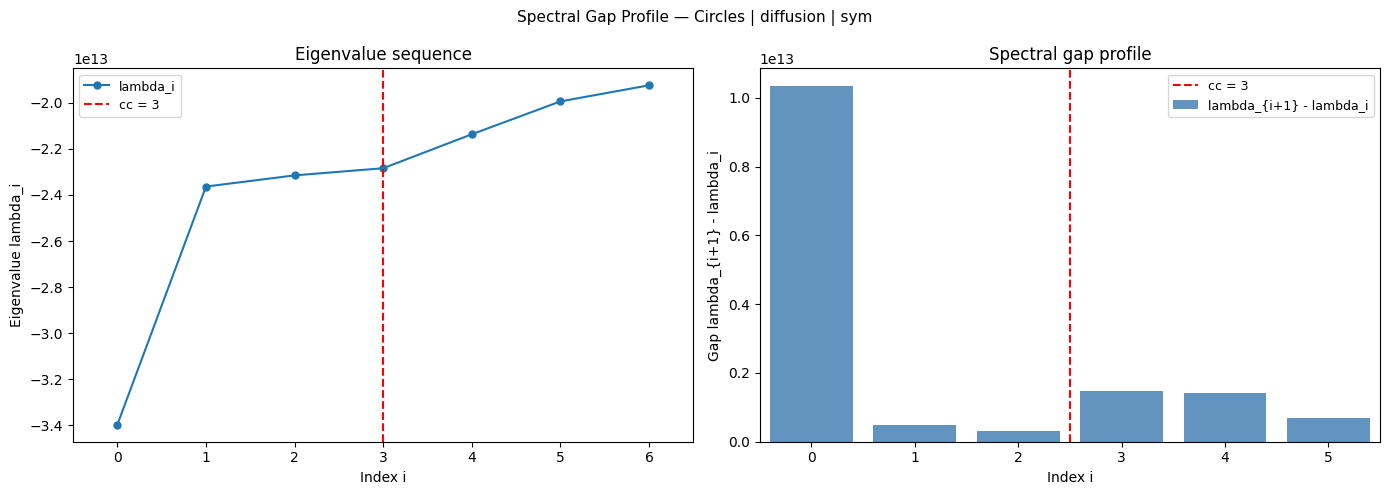

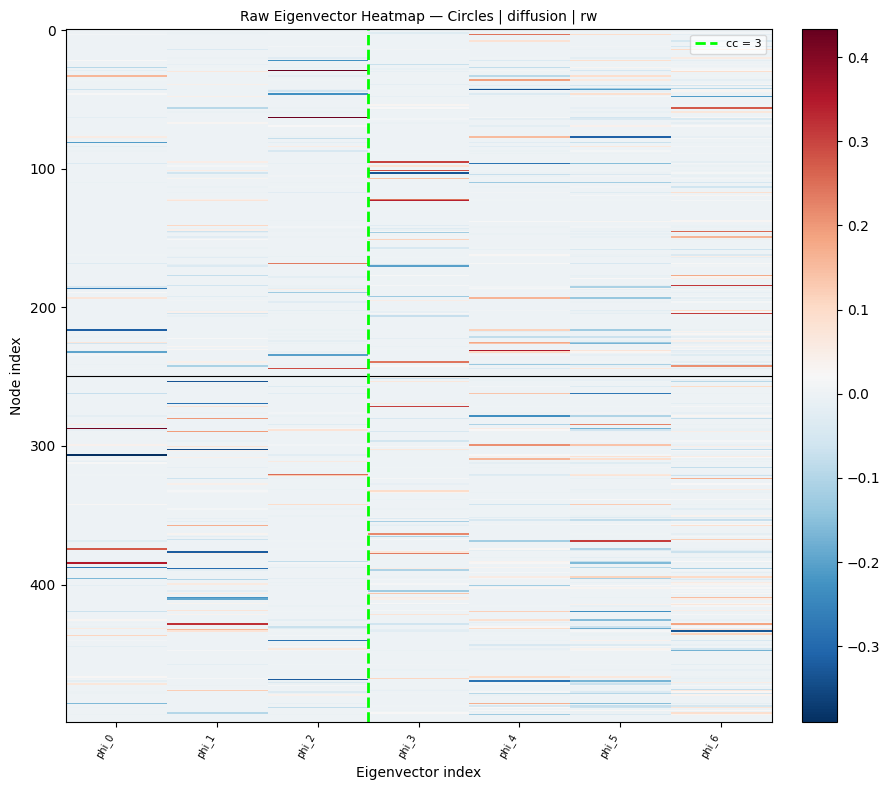

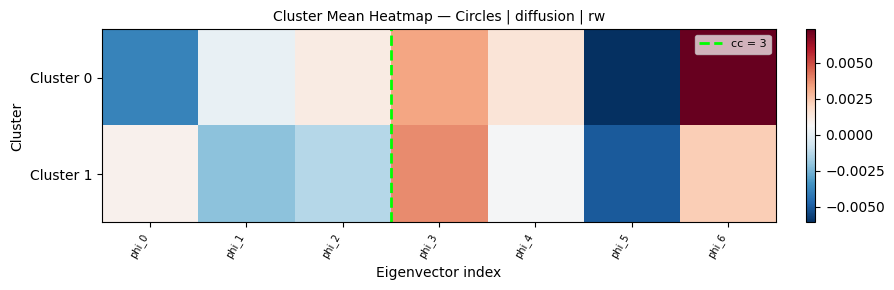

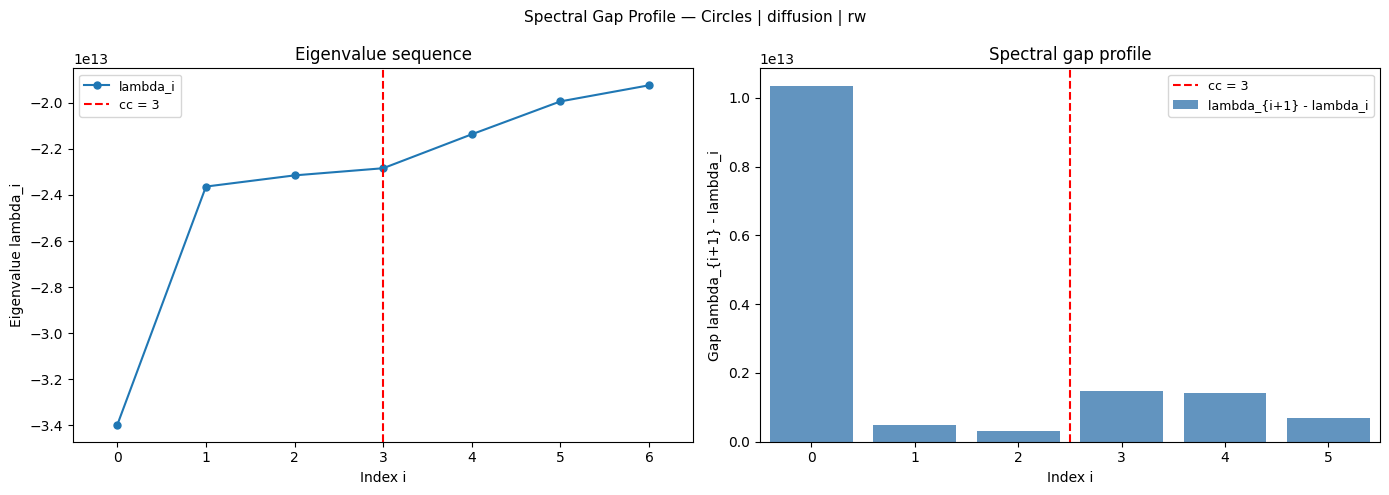

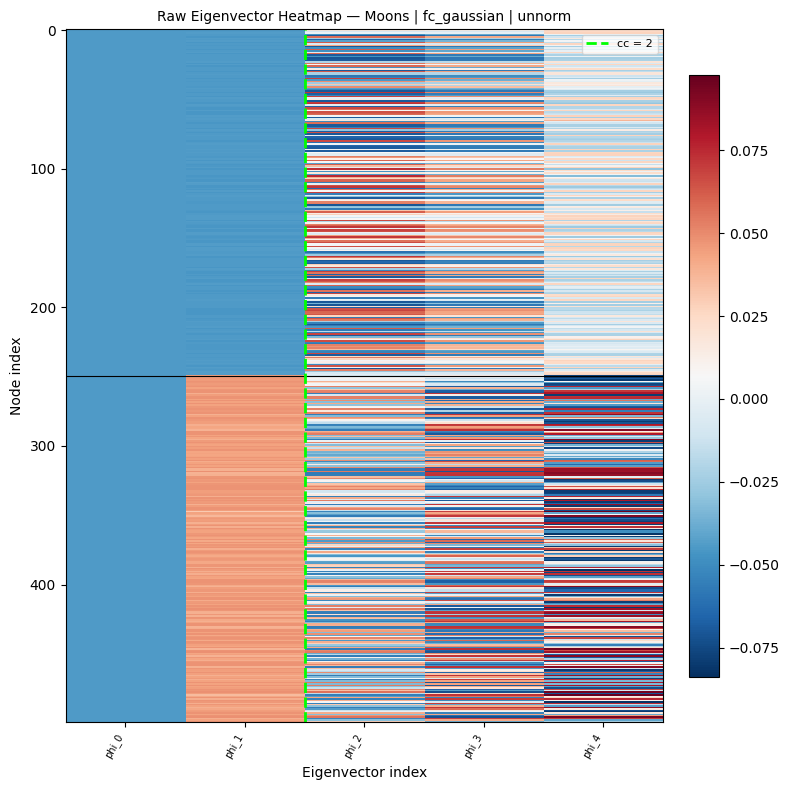

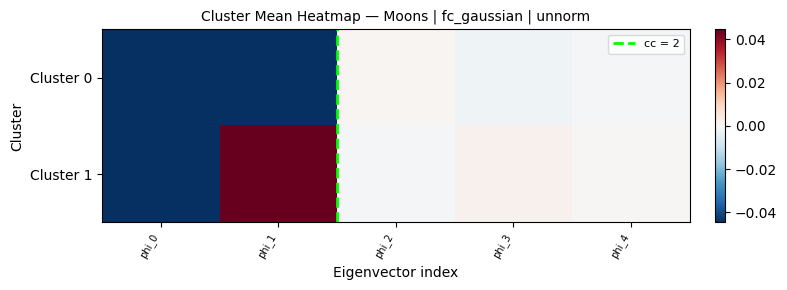

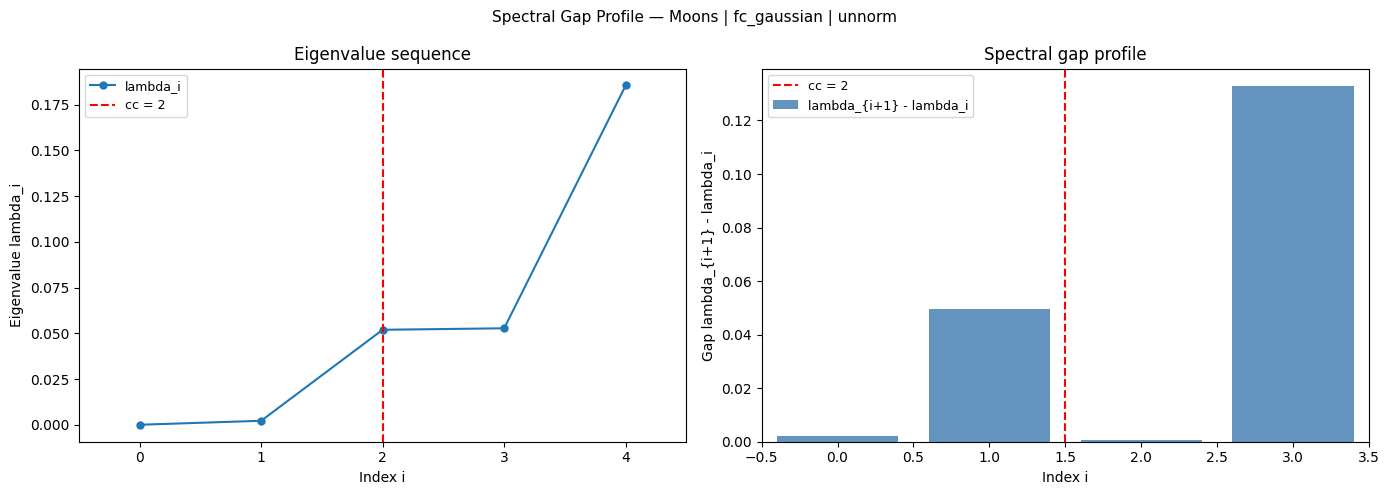

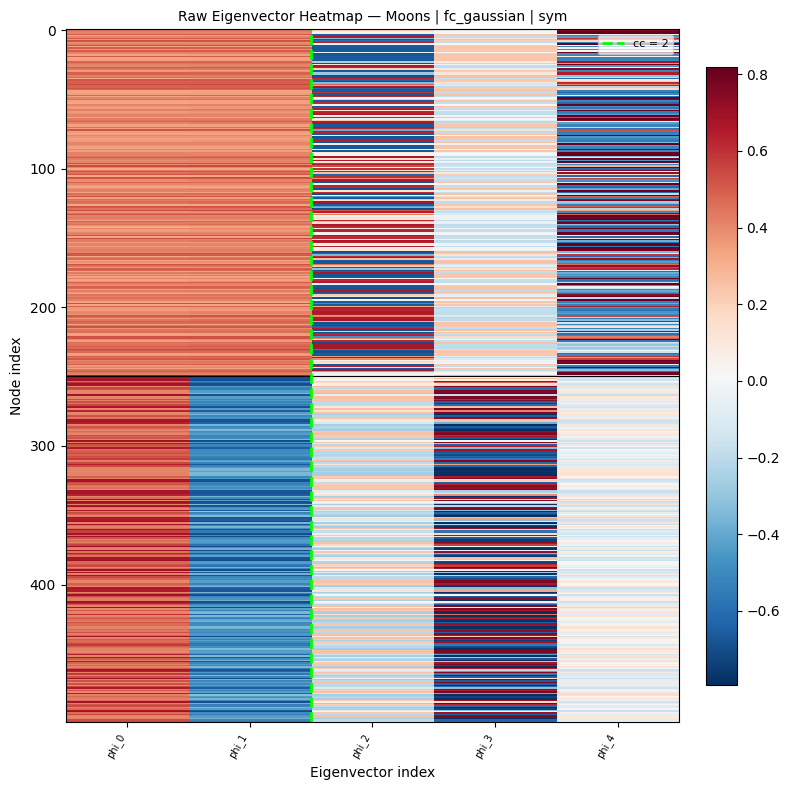

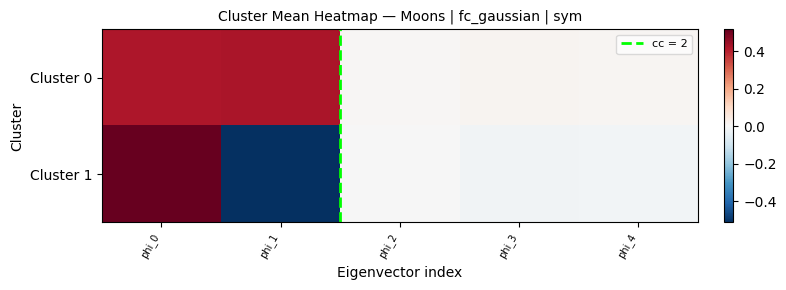

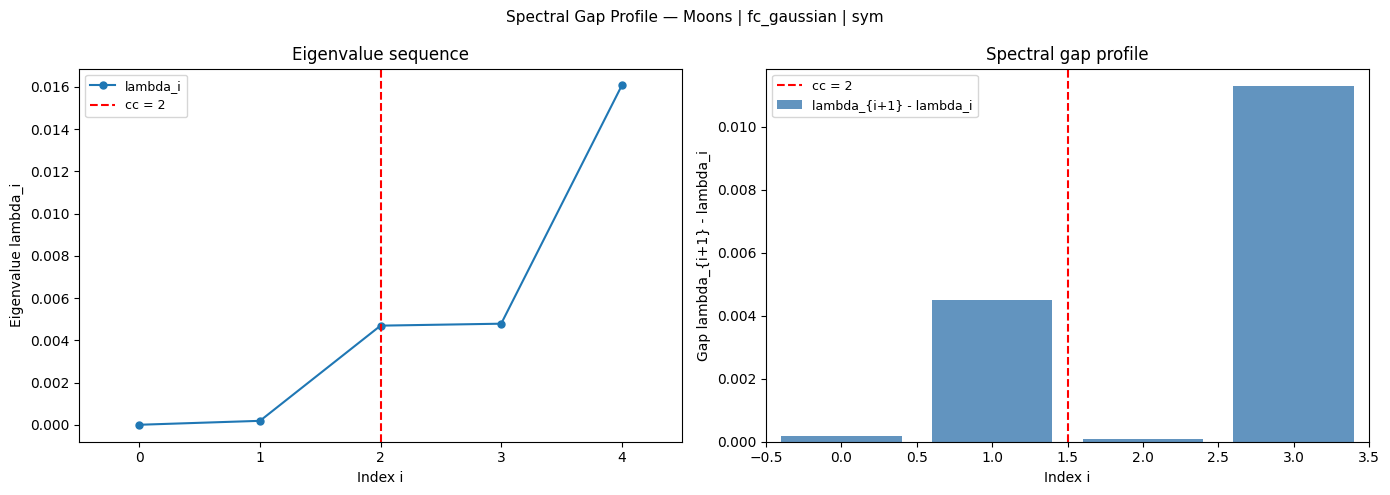

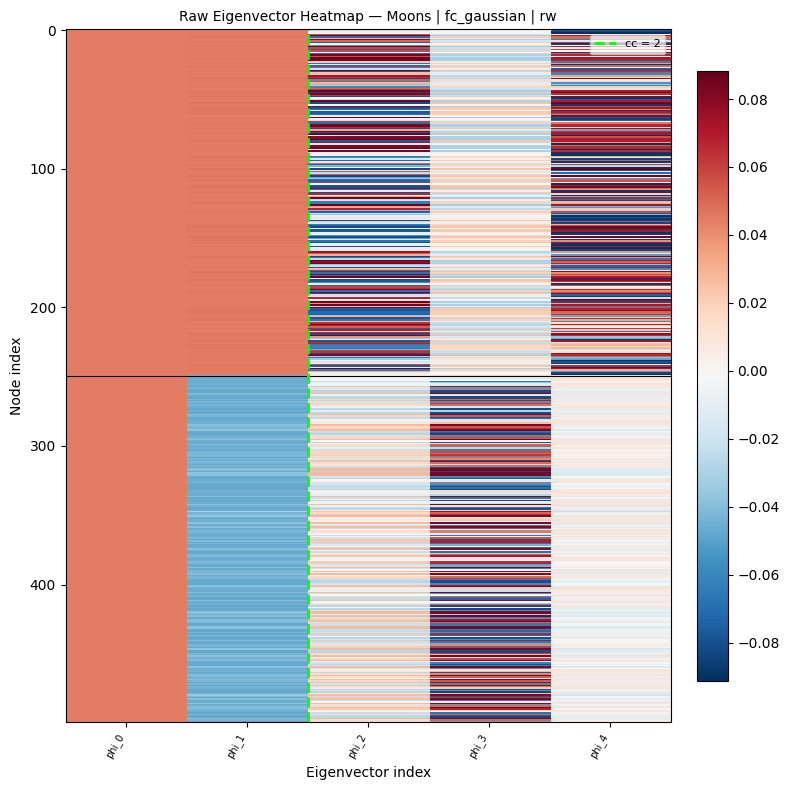

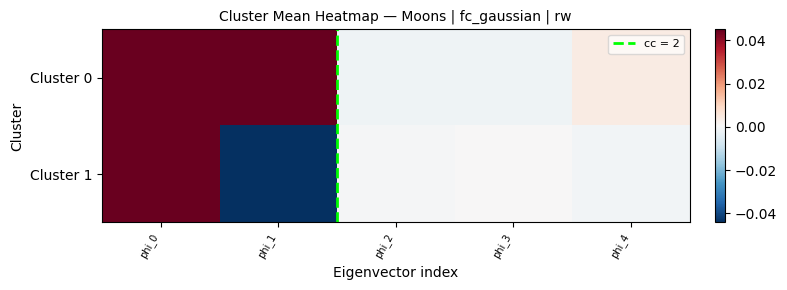

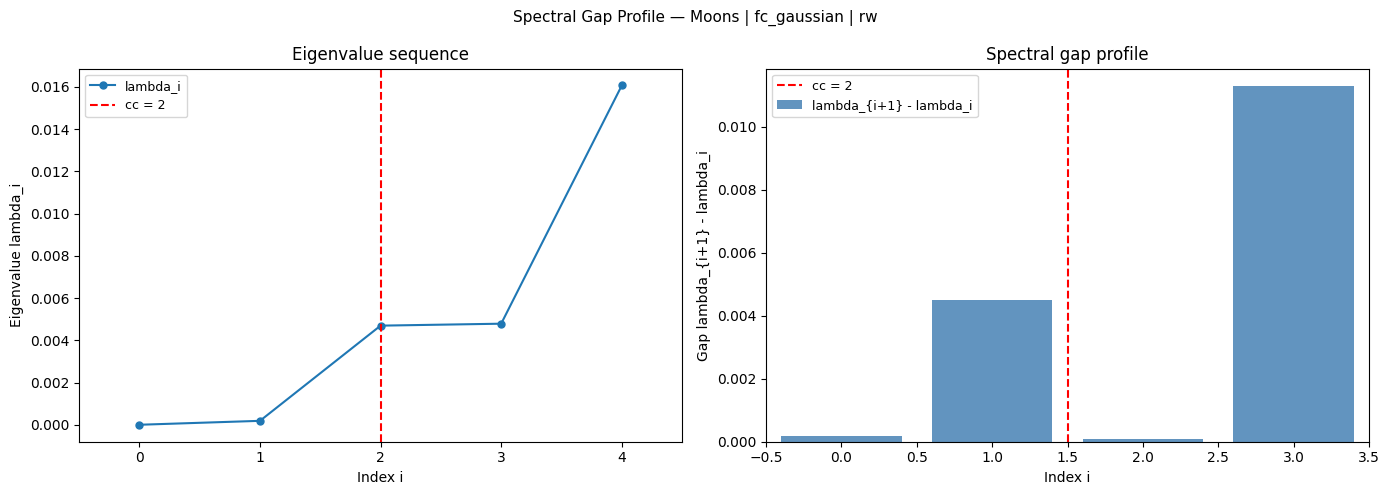

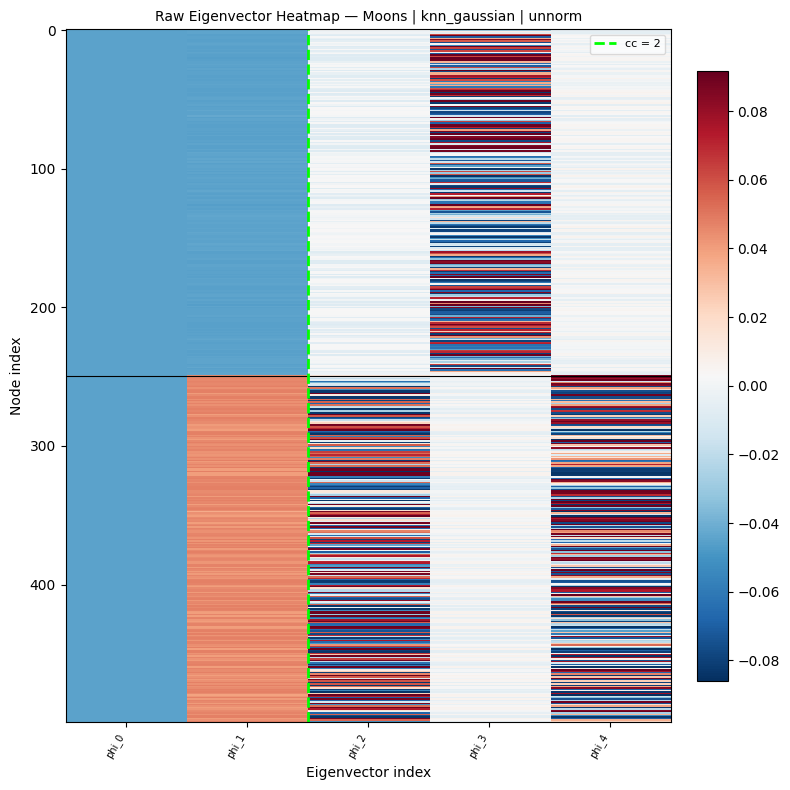

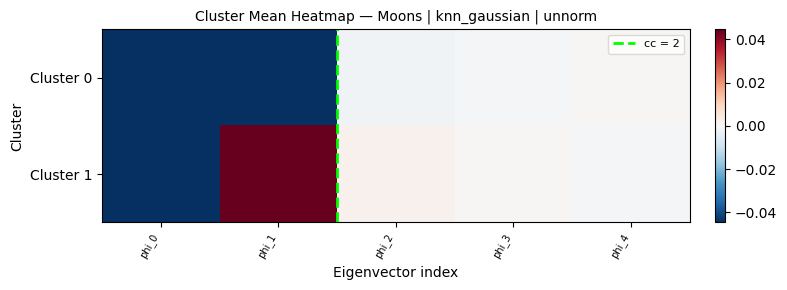

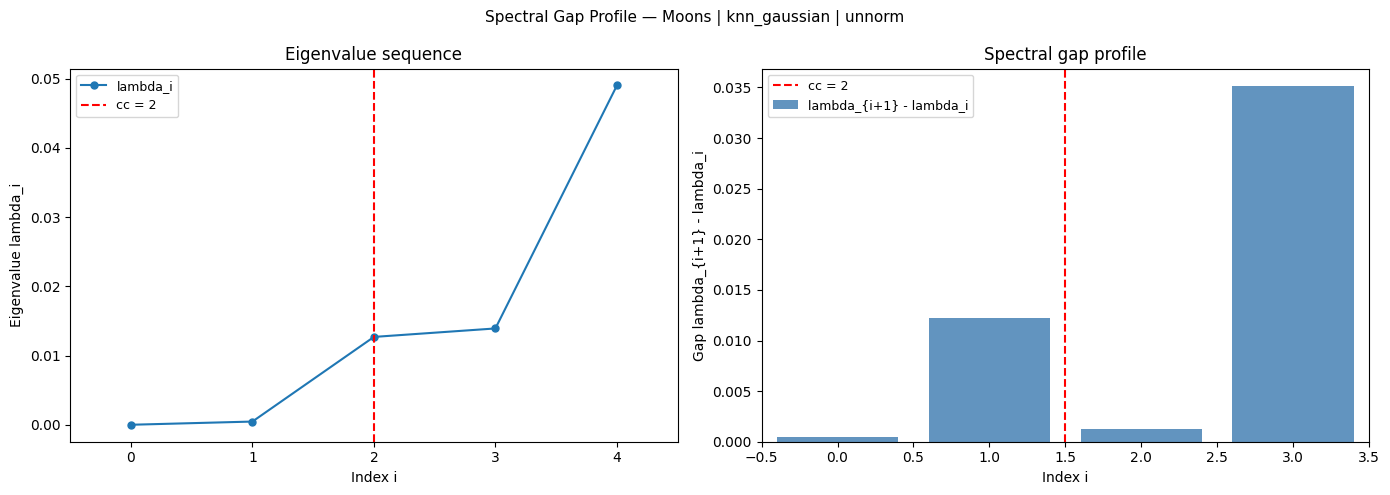

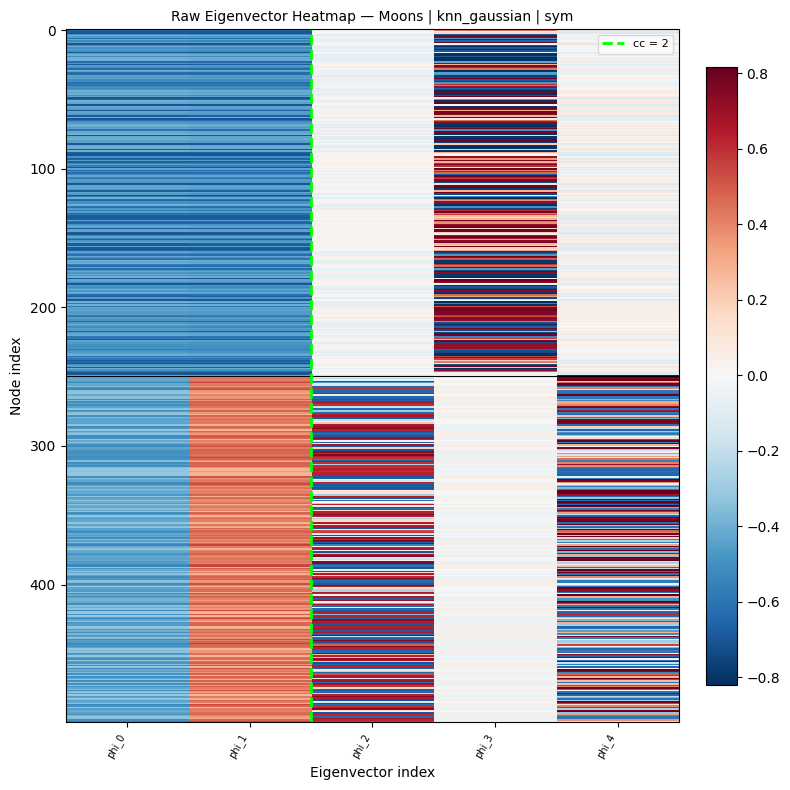

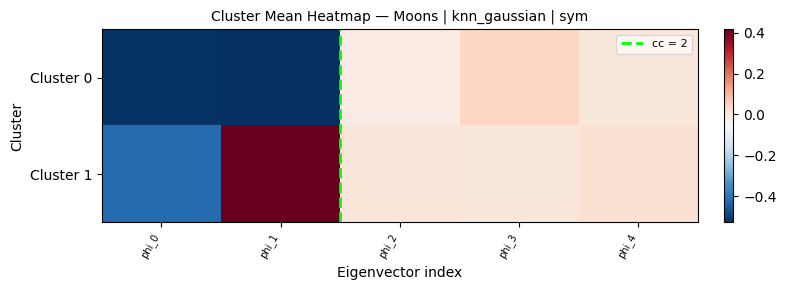

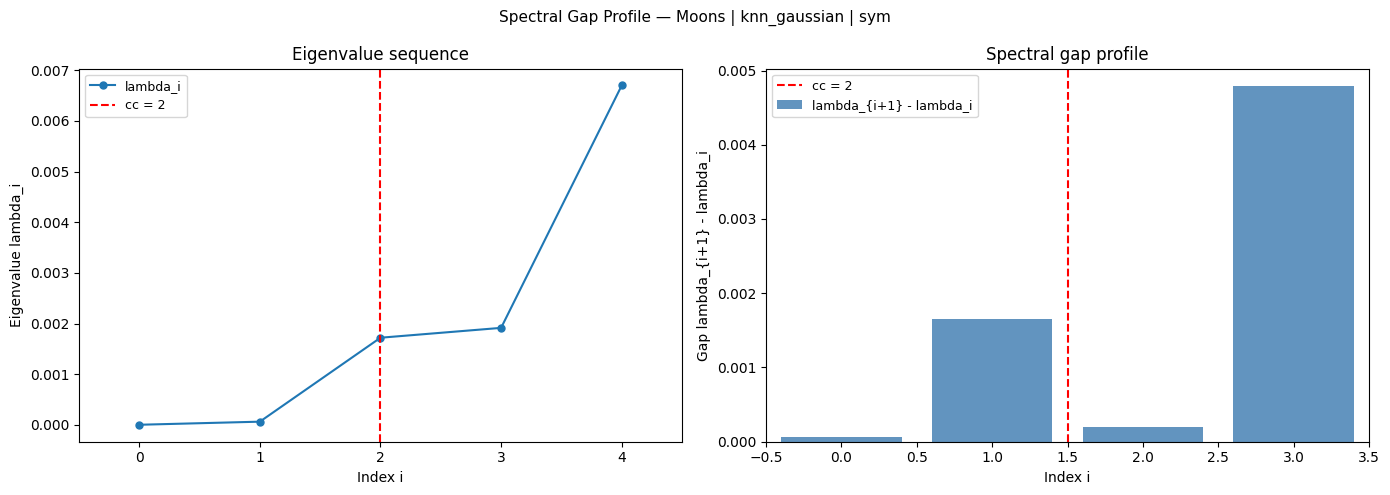

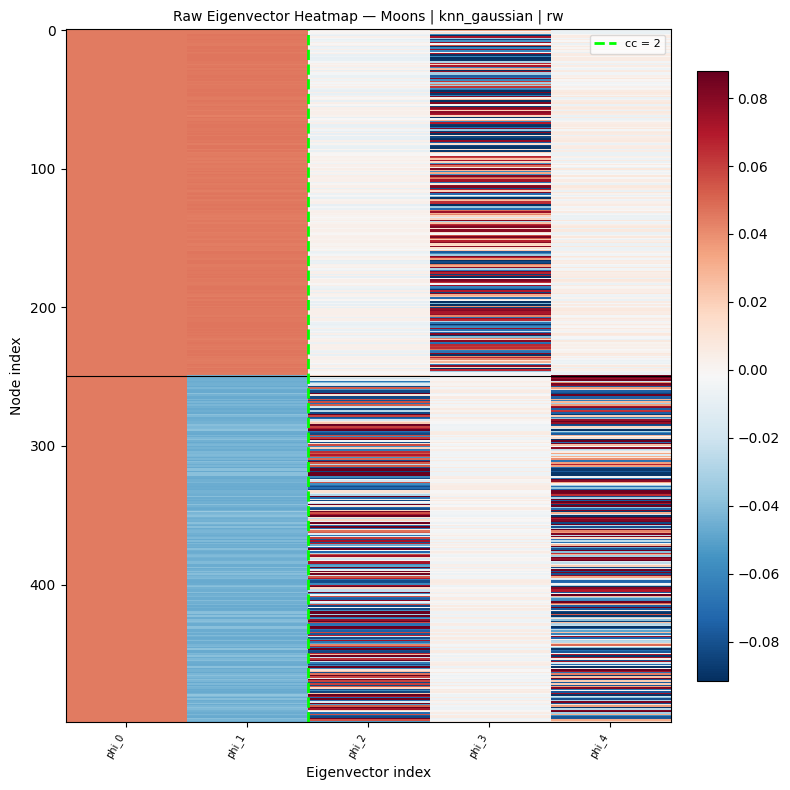

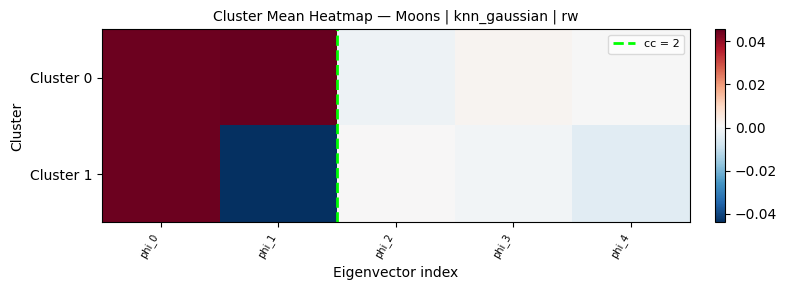

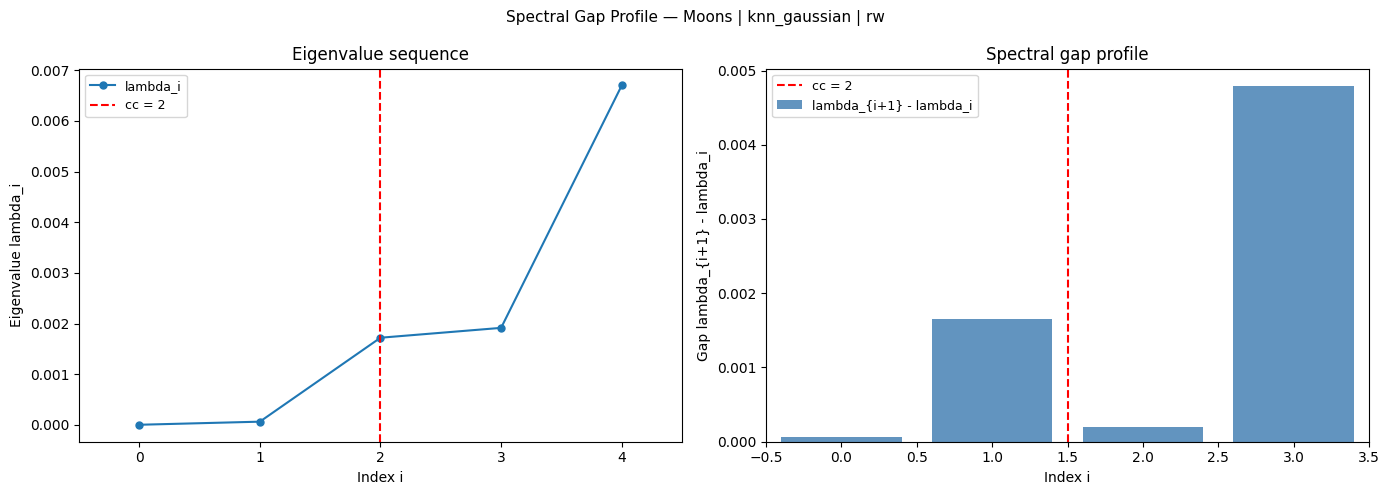

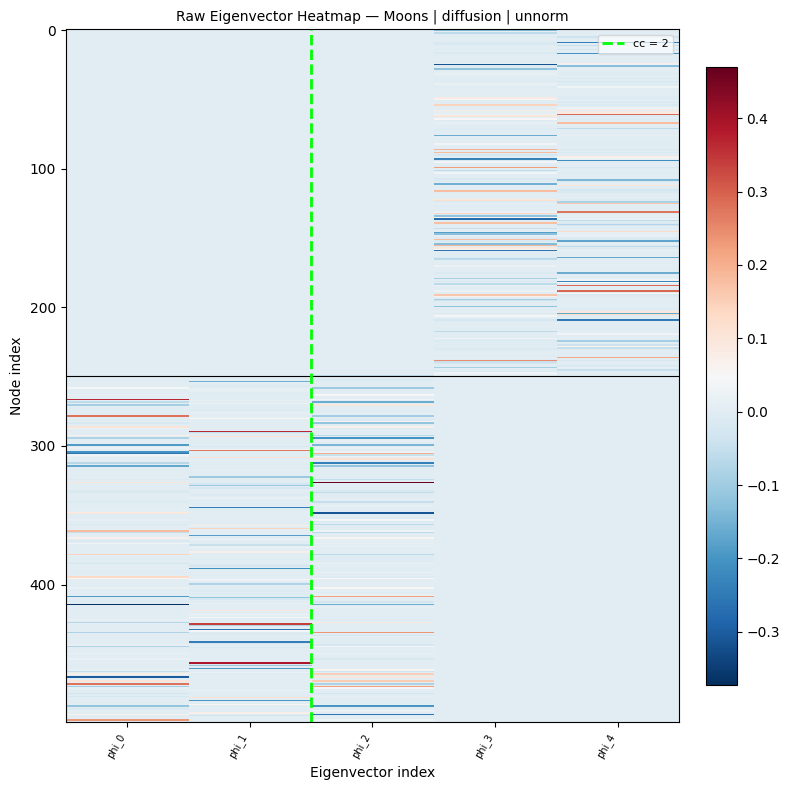

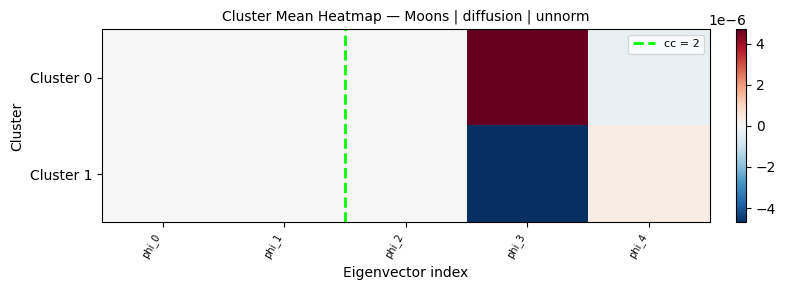

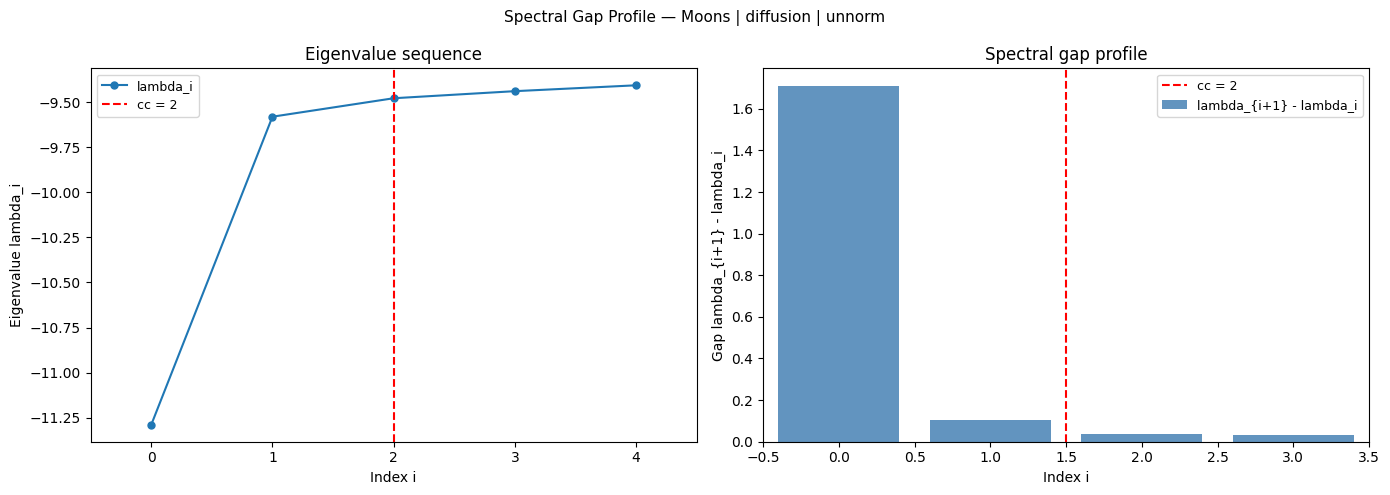

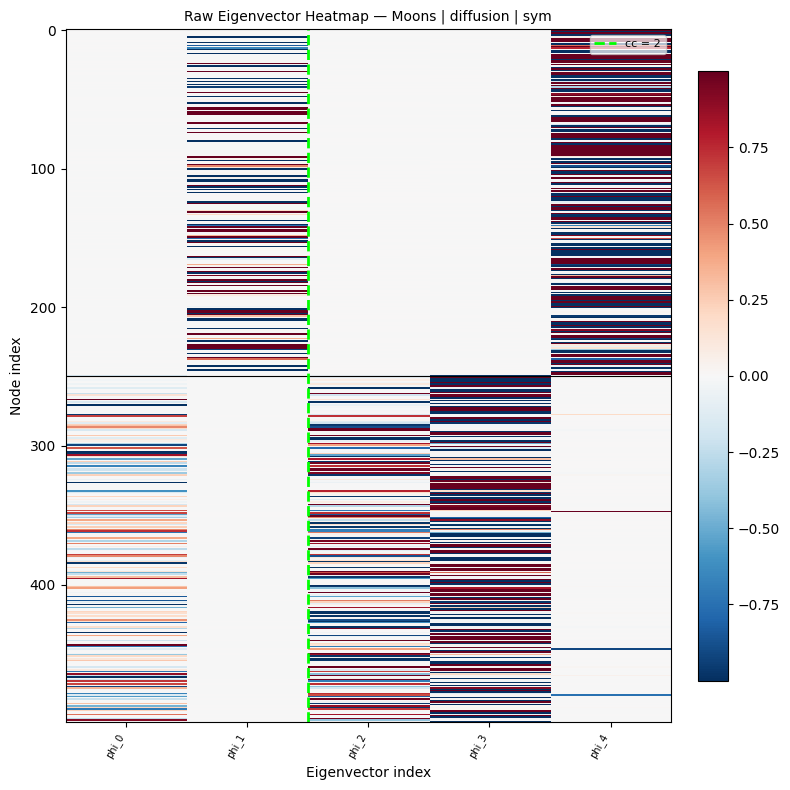

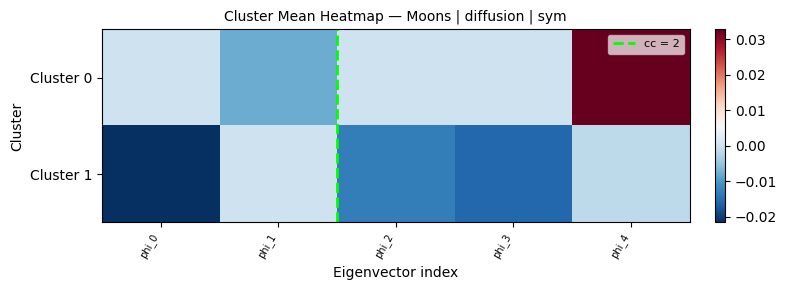

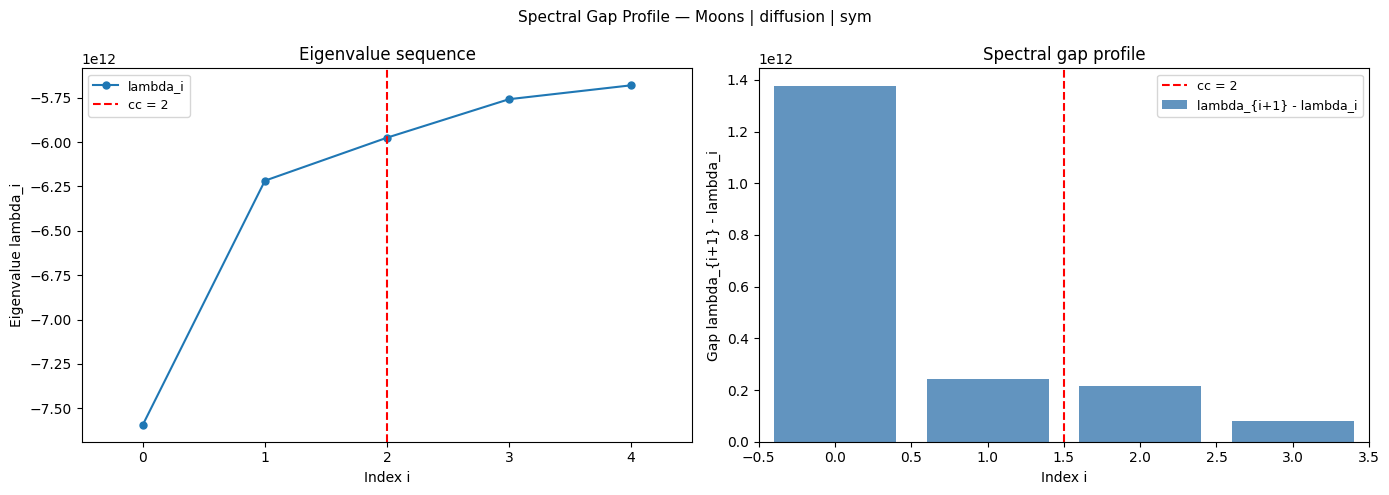

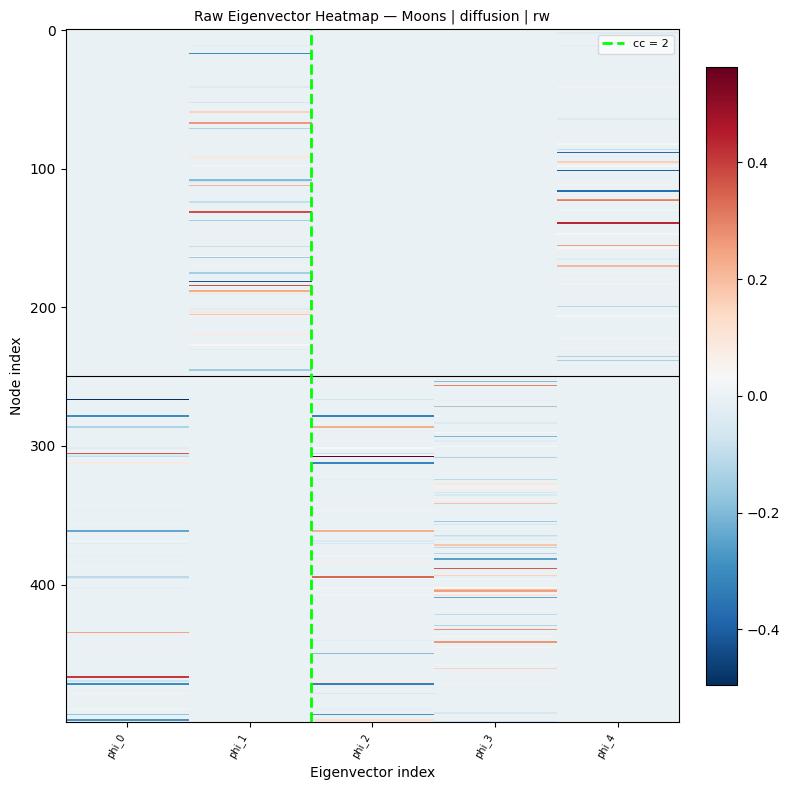

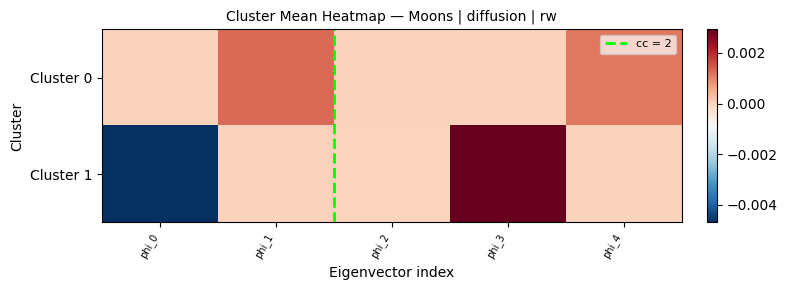

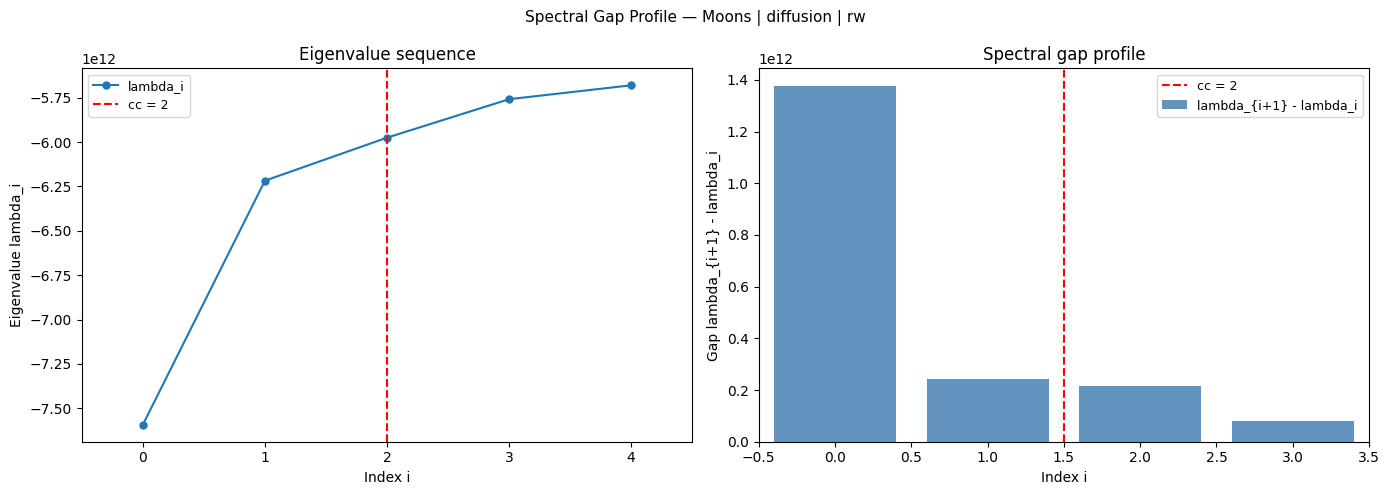

In [19]:
for ds_name in datasets:
    ds_cfg        = CONFIG["datasets"][ds_name]
    cc            = ds_cfg["cc"]
    q_max         = ds_cfg["q_max"]
    _, labels     = datasets[ds_name]

    for aff_name in AFFINITIES:
        for lap_name in LAPLACIANS:
            entry   = results[ds_name][aff_name][lap_name]
            U       = entry["U"]
            lambdas = entry["lambdas"]
            combo   = f"{ds_name} | {aff_name} | {lap_name}"

            # --- Function 1: Raw Eigenvector Heatmap ---
            # q=q_max shows all eigenvectors; replace with a range() loop to sweep q
            plot_raw_eigenvector_heatmap(
                Phi=U, labels=labels, cc=cc, q=q_max,
                title=f"Raw Eigenvector Heatmap — {combo}",
            )
            plt.show()

            # --- Function 2: Cluster Mean Heatmap ---
            plot_cluster_mean_heatmap(
                Phi=U, labels=labels, cc=cc, q=q_max,
                title=f"Cluster Mean Heatmap — {combo}",
            )
            plt.show()

            # --- Function 3: Spectral Gap Profile ---
            plot_spectral_gap(
                lambdas=lambdas, cc=cc,
                title=f"Spectral Gap Profile — {combo}",
            )
            plt.show()